170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
[Mini-batch GD (SGD)] epoch  10/100 | avg train loss = 1.7117
[Mini-batch GD (SGD)] epoch  20/100 | avg train loss = 1.5216
[Mini-batch GD (SGD)] epoch  30/100 | avg train loss = 1.4288
[Mini-batch GD (SGD)] epoch  40/100 | avg train loss = 1.3950
[Mini-batch GD (SGD)] epoch  50/100 | avg train loss = 1.3241
[Mini-batch GD (SGD)] epoch  60/100 | avg train loss = 1.2748
[Mini-batch GD (SGD)] epoch  70/100 | avg train loss = 1.2239
[Mini-batch GD (SGD)] epoch  80/100 | avg train loss = 1.1930
[Mini-batch GD (SGD)] epoch  90/100 | avg train loss = 1.1828
[Mini-batch GD (SGD)] epoch 100/100 | avg train loss = 1.1453
[AdaGrad] epoch  10/100 | avg train loss = 1.5568
[AdaGrad] epoch  20/100 | avg train loss = 1.3615
[AdaGrad] epoch  30/100 | avg train loss = 1.2672
[AdaGrad] epoch  40/100 | avg train loss = 1.2375
[AdaGrad] epoch  50/100 | avg train loss = 1.1657
[AdaGrad] epoch  60/100 | avg train loss = 1.1131
[AdaGrad] epoch  70/100 | 

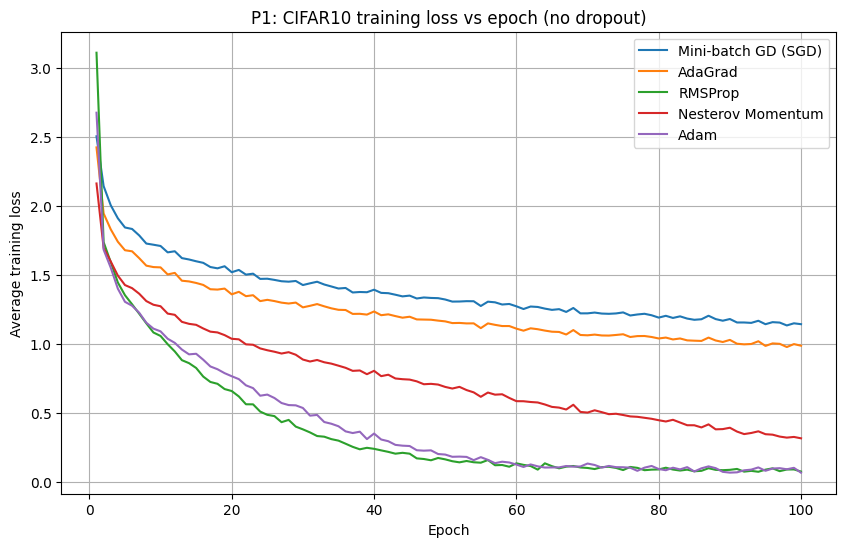

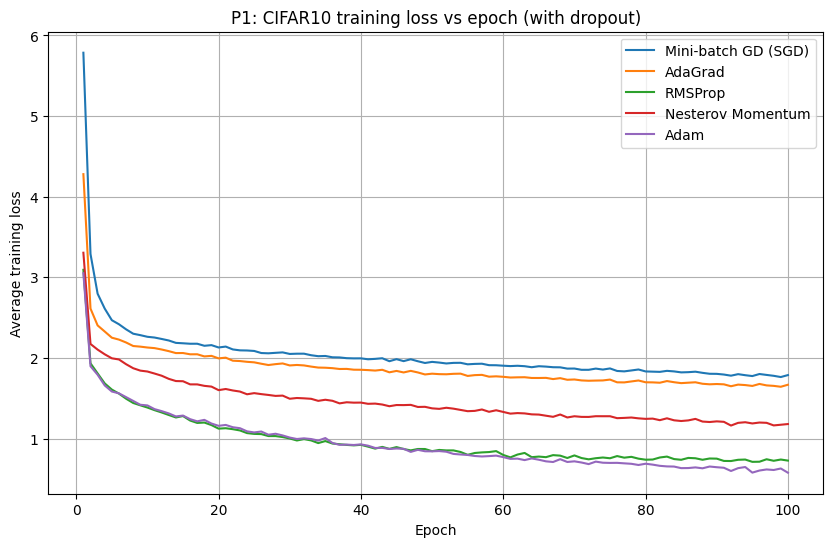

In [ ]:
#P1: Optimiser comparison

import os, random, numpy as np, tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

#Reproducibility

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Make ops more deterministic
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_seed(0)

#CIFAR10 loading

CIFAR_MEAN = tf.constant([0.4914, 0.4822, 0.4465], dtype=tf.float32)
CIFAR_STD  = tf.constant([0.2023, 0.1994, 0.2010], dtype=tf.float32)

def load_cifar10_arrays(mean=CIFAR_MEAN, std=CIFAR_STD):
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test  = x_test.astype(np.float32) / 255.0

    #Normalise

    x_train = (x_train - mean.numpy()) / std.numpy()
    x_test  = (x_test  - mean.numpy()) / std.numpy()

    #Validation split (same pattern as starter notebook): last 10k for val

    x_val, y_val = x_train[-10000:], y_train[-10000:]
    x_train, y_train = x_train[:-10000], y_train[:-10000]

    #Squeeze labels to shape (N,)

    y_train = y_train.squeeze().astype(np.int32)
    y_val   = y_val.squeeze().astype(np.int32)
    y_test  = y_test.squeeze().astype(np.int32)

    return x_train, y_train, x_val, y_val, x_test, y_test

x_train, y_train, x_val, y_val, x_test, y_test = load_cifar10_arrays()

#P1 epoch dataset: shuffle WHOLE train set, then take first 50 mini-batches

def make_p1_epoch_dataset(x, y, batch_size: int, epoch_seed: int, batches_per_epoch: int = 50):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    # IMPORTANT: buffer_size=len(x) => full-dataset shuffle (matches brief intention)
    ds = ds.shuffle(buffer_size=len(x), seed=epoch_seed, reshuffle_each_iteration=False)
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.take(batches_per_epoch)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

#P1 CNN model

def build_p1_cnn(
    filters=(32, 64, 128),
    dropout_conv: float = 0.0,
    dropout_fc: float = 0.0,
):
    he = keras.initializers.HeNormal()  #He init for ReLU nets

    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs
    for f in filters:
        x = keras.layers.Conv2D(
            filters=f,
            kernel_size=(5, 5),
            strides=1,
            padding="same",          #needed to keep shapes feasible for 3x (conv+pool)
            kernel_initializer=he
        )(x)
        x = keras.layers.ReLU()(x)
        x = keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
        if dropout_conv > 0:
            x = keras.layers.Dropout(rate=dropout_conv)(x)

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(1000, kernel_initializer=he)(x)
    x = keras.layers.ReLU()(x)
    if dropout_fc > 0:
        x = keras.layers.Dropout(rate=dropout_fc)(x)

    logits = keras.layers.Dense(10, kernel_initializer=he)(x)  # logits
    return keras.Model(inputs, logits)

#Train step (compiled for speed)

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

def make_train_step(model, optimizer):
    @tf.function
    def _step(x, y):
        with tf.GradientTape() as tape:
            logits = model(x, training=True)
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))
        return loss
    return _step

def run_p1_experiment(
    optimizer_name: str,
    optimizer_ctor,
    dropout_conv: float,
    dropout_fc: float,
    batch_size: int = 128,
    lr: float = 1e-3,
    epochs: int = 100,
    batches_per_epoch: int = 50,
    base_seed: int = 123,
):
    #Build model once and save initial weights for perfect fairness across optimisers

    set_seed(base_seed)
    model = build_p1_cnn(dropout_conv=dropout_conv, dropout_fc=dropout_fc)

    #Create weights

    _ = model(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)
    init_weights = model.get_weights()

    #Fresh model + fresh optimiser (same initial weights)

    set_seed(base_seed)
    model = build_p1_cnn(dropout_conv=dropout_conv, dropout_fc=dropout_fc)
    _ = model(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)
    model.set_weights(init_weights)

    optimizer = optimizer_ctor(lr)
    train_step_fn = make_train_step(model, optimizer)

    epoch_losses = []
    for epoch in range(epochs):
        ds_epoch = make_p1_epoch_dataset(
            x_train, y_train,
            batch_size=batch_size,
            epoch_seed=base_seed + epoch,          #deterministic shuffle per epoch
            batches_per_epoch=batches_per_epoch
        )

        m = keras.metrics.Mean()
        for xb, yb in ds_epoch:
            loss = train_step_fn(xb, yb)
            m.update_state(loss)
        epoch_losses.append(float(m.result()))

        if (epoch + 1) % 10 == 0:
            print(f"[{optimizer_name}] epoch {epoch+1:3d}/{epochs} | avg train loss = {epoch_losses[-1]:.4f}")

    return epoch_losses

#Optimiser constructors

def opt_sgd(lr):
    return keras.optimizers.SGD(learning_rate=lr)

def opt_adagrad(lr):
    return keras.optimizers.Adagrad(learning_rate=lr)

def opt_rmsprop(lr):
    return keras.optimizers.RMSprop(learning_rate=lr)

def opt_nesterov(lr):
    return keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

def opt_adam(lr):
    return keras.optimizers.Adam(learning_rate=lr)

OPTIMISERS = [
    ("Mini-batch GD (SGD)", opt_sgd),
    ("AdaGrad",             opt_adagrad),
    ("RMSProp",             opt_rmsprop),
    ("Nesterov Momentum",   opt_nesterov),
    ("Adam",                opt_adam),
]

#Run 1: NO dropout

EPOCHS = 100
BATCH_SIZE = 128
LR = 1e-3
BATCHES_PER_EPOCH = 50

loss_curves_no_dropout = {}
for name, ctor in OPTIMISERS:
    loss_curves_no_dropout[name] = run_p1_experiment(
        optimizer_name=name,
        optimizer_ctor=ctor,
        dropout_conv=0.0,
        dropout_fc=0.0,
        batch_size=BATCH_SIZE,
        lr=LR,
        epochs=EPOCHS,
        batches_per_epoch=BATCHES_PER_EPOCH,
        base_seed=123
    )

#Run 2: WITH dropout

# "Appropriate" starting rates
DROP_CONV = 0.25
DROP_FC   = 0.50

loss_curves_dropout = {}
for name, ctor in OPTIMISERS:
    loss_curves_dropout[name] = run_p1_experiment(
        optimizer_name=name,
        optimizer_ctor=ctor,
        dropout_conv=DROP_CONV,
        dropout_fc=DROP_FC,
        batch_size=BATCH_SIZE,
        lr=LR,
        epochs=EPOCHS,
        batches_per_epoch=BATCHES_PER_EPOCH,
        base_seed=123
    )

#Plotting

def plot_loss_curves(loss_dict, title):
    plt.figure(figsize=(10, 6))
    for name, curve in loss_dict.items():
        plt.plot(np.arange(1, len(curve)+1), curve, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Average training loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(loss_curves_no_dropout, "P1: CIFAR10 training loss vs epoch (no dropout)")
plot_loss_curves(loss_curves_dropout,   "P1: CIFAR10 training loss vs epoch (with dropout)")

In [ ]:
#Google Drive mount (for saving checkpoints / P3 outputs)

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted at /content/drive")


Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [1]:
#P2: Setup + Data

import numpy as np, tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

#Speed toggle

#Mixed precision

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

def set_seed(seed: int = 0):
    import random, os
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(0)

#CIFAR10 mean/std

CIFAR_MEAN = tf.constant([0.4914, 0.4822, 0.4465], dtype=tf.float32)
CIFAR_STD  = tf.constant([0.2023, 0.1994, 0.2010], dtype=tf.float32)

def load_cifar10(val_size=5000):
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

    x_train = x_train.astype(np.float32) / 255.0
    x_test  = x_test.astype(np.float32) / 255.0

    x_train = (x_train - CIFAR_MEAN.numpy()) / CIFAR_STD.numpy()
    x_test  = (x_test  - CIFAR_MEAN.numpy()) / CIFAR_STD.numpy()

    y_train = y_train.squeeze().astype(np.int32)
    y_test  = y_test.squeeze().astype(np.int32)

    # deterministic val split (last val_size points)
    x_val, y_val = x_train[-val_size:], y_train[-val_size:]
    x_train, y_train = x_train[:-val_size], y_train[:-val_size]

    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

(train_x, train_y), (val_x, val_y), (test_x, test_y) = load_cifar10(val_size=5000)

def make_ds(x, y, batch_size, training=False, augment_fn=None, shuffle_buffer=45000):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(shuffle_buffer, reshuffle_each_iteration=True)
    if augment_fn is not None:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

#CIFAR augmentations

#Base augmentation for CIFAR-10: random horizontal flip + pad(4) + random crop back to 32x32.

def augment_basic(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.resize_with_crop_or_pad(x, 40, 40)
    x = tf.image.random_crop(x, size=(32, 32, 3))
    return x, y

#Cutout (a simple regularising augmentation): zero out a random square region.
#Apply it on the normalised image; 0 corresponds to the mean after standardisation.

def _cutout_single(x, mask_size=16):
    mask_size = tf.cast(mask_size, tf.int32)
    h = tf.shape(x)[0]
    w = tf.shape(x)[1]

    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)

    y1 = tf.clip_by_value(cy - mask_size // 2, 0, h)
    y2 = tf.clip_by_value(cy + mask_size // 2, 0, h)
    x1 = tf.clip_by_value(cx - mask_size // 2, 0, w)
    x2 = tf.clip_by_value(cx + mask_size // 2, 0, w)

    #Build a mask of ones and set the cutout region to zero.

    mask = tf.ones([h, w], dtype=x.dtype)
    mask = tf.tensor_scatter_nd_update(
        mask,
        indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing="ij"), axis=-1), [-1, 2]),
        updates=tf.zeros([(y2 - y1) * (x2 - x1)], dtype=x.dtype),
    )
    mask = tf.expand_dims(mask, axis=-1)  # (H, W, 1)
    return x * mask

def augment_cutout(x, y, mask_size=16):
    x, y = augment_basic(x, y)
    x = _cutout_single(x, mask_size=mask_size)
    return x, y

#Convenience wrappers (so augment_fn has signature (x,y)->(x,y))

def augment_cutout16(x, y):
    return augment_cutout(x, y, mask_size=16)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
#P2: Model builders (3 combos)

def make_loss(label_smoothing=0.0):
    ls = float(label_smoothing)

    if ls <= 0.0:
        base = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        def _loss(y_true, y_pred):
            y_pred = tf.cast(y_pred, tf.float32)
            return base(y_true, y_pred)
        return _loss

    num_classes = 10
    def _loss(y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y = y * (1.0 - ls) + (ls / num_classes)
        return tf.reduce_mean(
            keras.losses.categorical_crossentropy(y, y_pred, from_logits=True)
        )
    return _loss


def compile_model(model, optimizer, label_smoothing=0.0):
    def top1_acc(y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        return keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

    def top5_acc(y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        return keras.metrics.sparse_top_k_categorical_accuracy(y_true, y_pred, k=5)

    #Give stable names for history keys

    top1_acc.__name__ = "top1_acc"
    top5_acc.__name__ = "top5_acc"

    model.compile(
        optimizer=optimizer,
        loss=make_loss(label_smoothing=label_smoothing),
        metrics=[top1_acc, top5_acc],
        # If your TF supports it, this can speed things up:
        # jit_compile=True
    )
    return model


#Combo 1: DenseNet-BC for CIFAR-10 (high-performance, architecture-diverse)

def build_densenet_bc_cifar(depth=190, growth_rate=40, compression=0.5, weight_decay=1e-4, dropout_rate=0.0):
#Keeps the input at 32x32 resolution
    if (depth - 4) % 6 != 0:
        raise ValueError("For DenseNet-BC, depth should satisfy (depth - 4) % 6 == 0")

    n_layers_per_block = (depth - 4) // 6  #BC variant: each dense layer has bottleneck+3x3 conv
    k = int(growth_rate)
    theta = float(compression)
    reg = keras.regularizers.l2(weight_decay)

    inputs = keras.Input(shape=(32, 32, 3))
    x = keras.layers.Conv2D(2 * k, 3, padding="same", use_bias=False, kernel_regularizer=reg)(inputs)

    def dense_layer(x):
        y = keras.layers.BatchNormalization()(x)
        y = keras.layers.ReLU()(y)
        y = keras.layers.Conv2D(4 * k, 1, padding="same", use_bias=False, kernel_regularizer=reg)(y)

        y = keras.layers.BatchNormalization()(y)
        y = keras.layers.ReLU()(y)
        y = keras.layers.Conv2D(k, 3, padding="same", use_bias=False, kernel_regularizer=reg)(y)

        if dropout_rate and dropout_rate > 0:
            y = keras.layers.Dropout(dropout_rate)(y)

        x = keras.layers.Concatenate()([x, y])
        return x

    def dense_block(x, n_layers):
        for _ in range(n_layers):
            x = dense_layer(x)
        return x

    def transition(x):
        y = keras.layers.BatchNormalization()(x)
        y = keras.layers.ReLU()(y)
        out_channels = max(1, int(int(y.shape[-1]) * theta))
        y = keras.layers.Conv2D(out_channels, 1, padding="same", use_bias=False, kernel_regularizer=reg)(y)
        y = keras.layers.AveragePooling2D(pool_size=2, strides=2, padding="same")(y)
        return y

    x = dense_block(x, n_layers_per_block)
    x = transition(x)

    x = dense_block(x, n_layers_per_block)
    x = transition(x)

    x = dense_block(x, n_layers_per_block)

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    logits = keras.layers.Dense(10)(x)

    return keras.Model(inputs, logits, name=f"DenseNetBC_L{depth}_k{k}")

#Combo 2: WideResNet-28-10 (ResNet-family)

def _wrn_basic_block(x, out_filters, stride, dropout_rate, weight_decay):
    reg = keras.regularizers.l2(weight_decay)

    in_filters = int(x.shape[-1])

    # Pre-activation style: BN -> ReLU -> Conv -> BN -> ReLU -> (Dropout) -> Conv
    y = keras.layers.BatchNormalization()(x)
    y = keras.layers.ReLU()(y)
    y = keras.layers.Conv2D(out_filters, 3, strides=stride, padding="same",
                            use_bias=False, kernel_regularizer=reg)(y)

    y = keras.layers.BatchNormalization()(y)
    y = keras.layers.ReLU()(y)
    if dropout_rate and dropout_rate > 0:
        y = keras.layers.Dropout(dropout_rate)(y)
    y = keras.layers.Conv2D(out_filters, 3, strides=1, padding="same",
                            use_bias=False, kernel_regularizer=reg)(y)

    if stride != 1 or in_filters != out_filters:
        shortcut = keras.layers.Conv2D(out_filters, 1, strides=stride, padding="same",
                                       use_bias=False, kernel_regularizer=reg)(x)
    else:
        shortcut = x

    out = keras.layers.Add()([y, shortcut])
    return out

def build_wrn_28_10(weight_decay=5e-4, dropout_rate=0.3, widen_factor=10):

    #WideResNet depth=28 => N=(28-4)/6 = 4 blocks per group

    N = 4
    k = int(widen_factor)
    reg = keras.regularizers.l2(weight_decay)

    inputs = keras.Input(shape=(32, 32, 3))
    x = keras.layers.Conv2D(16, 3, padding="same", use_bias=False, kernel_regularizer=reg)(inputs)

    #Group 1: 16*k, stride 1

    for i in range(N):
        x = _wrn_basic_block(x, 16 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    #Group 2: 32*k, first block stride 2 then stride 1

    x = _wrn_basic_block(x, 32 * k, stride=2, dropout_rate=dropout_rate, weight_decay=weight_decay)
    for i in range(N - 1):
        x = _wrn_basic_block(x, 32 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    #Group 3: 64*k, first block stride 2 then stride 1

    x = _wrn_basic_block(x, 64 * k, stride=2, dropout_rate=dropout_rate, weight_decay=weight_decay)
    for i in range(N - 1):
        x = _wrn_basic_block(x, 64 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    logits = keras.layers.Dense(10)(x)
    return keras.Model(inputs, logits, name="WRN_28_10")

#Combo 3: Transfer learning with EfficientNetB0

def build_efficientnet_transfer(trainable_layers=60, dropout=0.2):
    inputs = keras.Input(shape=(32, 32, 3))

    #IMPORTANT:
    #CIFAR pipeline standardises inputs (z-score). EfficientNetB0 pretrained on ImageNet
    #expects "image-like" inputs: float pixels in [0, 255]. Keras docs note EfficientNet
    #includes a Rescaling layer and preprocess_input is a pass-through; the expected range is [0,255].
    #So, undo CIFAR standardisation back to [0,1] and then scale to [0,255].

    x = keras.layers.Lambda(lambda t: tf.cast(t, tf.float32) * CIFAR_STD + CIFAR_MEAN, output_shape=lambda s: s, name='undo_cifar_norm')(inputs)
    x = keras.layers.Lambda(lambda t: tf.clip_by_value(t, 0.0, 1.0), output_shape=lambda s: s, name='clip_0_1')(x)
    x = keras.layers.Rescaling(255.0, name='to_0_255')(x)

    #Cast to float32 for the pretrained backbone (stability + matches expected dtype).

    x = keras.layers.Lambda(lambda t: tf.cast(t, tf.float32), output_shape=lambda s: s, name='cast_fp32')(x)

    x = keras.layers.Resizing(224, 224)(x)

    base = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_tensor=x, pooling="avg"
    )

    #Fine-tune only the last 'trainable_layers' layers (plus keep BatchNorm frozen for stability).

    base.trainable = True
    for layer in base.layers[:-trainable_layers]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    x = base.output
    x = keras.layers.Dropout(dropout)(x)
    logits = keras.layers.Dense(10)(x)
    return keras.Model(inputs, logits, name="EffNetB0_transfer")

In [ ]:
#P2: Training + per-epoch test eval + plotting

from dataclasses import dataclass

class TestEvalCallback(keras.callbacks.Callback):
    def __init__(self, test_ds):
        super().__init__()
        self.test_ds = test_ds
        self.test_loss = []
        self.test_top1 = []
        self.test_top5 = []

    def on_epoch_end(self, epoch, logs=None):
        res = self.model.evaluate(self.test_ds, verbose=0, return_dict=True)
        self.test_loss.append(float(res["loss"]))
        self.test_top1.append(float(res["top1_acc"]))
        self.test_top5.append(float(res["top5_acc"]))

def plot_p2_curves(run, title):
    epochs = np.arange(1, len(run["train_loss"]) + 1)

    plt.figure(figsize=(9,5))
    plt.plot(epochs, run["train_loss"], label="train loss")
    plt.plot(epochs, run["test_loss"],  label="test loss")
    plt.xlabel("Epoch"); plt.ylabel("Average loss"); plt.title(f"{title} — Loss")
    plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(epochs, 1 - np.array(run["train_top1"]), label="train top-1 error")
    plt.plot(epochs, 1 - np.array(run["test_top1"]),  label="test top-1 error")
    plt.xlabel("Epoch"); plt.ylabel("Top-1 error rate"); plt.title(f"{title} — Top-1 error")
    plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(epochs, 1 - np.array(run["train_top5"]), label="train top-5 error")
    plt.plot(epochs, 1 - np.array(run["test_top5"]),  label="test top-5 error")
    plt.xlabel("Epoch"); plt.ylabel("Top-5 error rate"); plt.title(f"{title} — Top-5 error")
    plt.grid(True); plt.legend(); plt.show()

@dataclass
class P2Config:
    name: str
    model_builder: callable
    batch_size: int
    epochs: int
    optimizer_builder: callable
    label_smoothing: float = 0.0
    augment_fn: callable = None

def run_p2_config(cfg: P2Config):
    set_seed(0)

    train_ds = make_ds(train_x, train_y, cfg.batch_size, training=True,
                       augment_fn=cfg.augment_fn)
    val_ds   = make_ds(val_x,   val_y,   cfg.batch_size, training=False)
    test_ds  = make_ds(test_x,  test_y,  cfg.batch_size, training=False)

    model = cfg.model_builder()

    steps_per_epoch = int(np.ceil(len(train_x) / cfg.batch_size))
    optimizer = cfg.optimizer_builder(steps_per_epoch=steps_per_epoch, epochs=cfg.epochs)

    compile_model(model, optimizer, label_smoothing=cfg.label_smoothing)

    test_cb = TestEvalCallback(test_ds)

    hist = model.fit(
        train_ds,
        epochs=cfg.epochs,
        validation_data=val_ds,
        callbacks=[test_cb],
        verbose=2
    )

    return {
        "name": cfg.name,
        "train_loss": hist.history["loss"],
        "train_top1": hist.history["top1_acc"],
        "train_top5": hist.history["top5_acc"],
        "test_loss":  test_cb.test_loss,
        "test_top1":  test_cb.test_top1,
        "test_top5":  test_cb.test_top5,
        "model": model,
        "cfg": cfg,
    }

#Training method builders

def adamw_cosine_builder(max_lr=1e-3, wd=1e-4, min_lr=1e-5):
    def _build(steps_per_epoch, epochs):
        total_steps = steps_per_epoch * epochs
        schedule = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=max_lr,
            decay_steps=total_steps,
            alpha=(min_lr / max_lr) if max_lr > 0 else 0.0
        )
        if hasattr(keras.optimizers, "AdamW"):
            return keras.optimizers.AdamW(learning_rate=schedule, weight_decay=wd)
        return keras.optimizers.Adam(learning_rate=schedule)
    return _build

class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, max_lr, total_steps, warmup_steps, min_lr=0.0):
        super().__init__()
        self.max_lr = float(max_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)

        #Linear warmup from 0 -> max_lr

        warmup_lr = self.max_lr * (step / tf.maximum(1.0, warmup_steps))

        #Cosine decay from max_lr -> min_lr

        t = (step - warmup_steps) / tf.maximum(1.0, total_steps - warmup_steps)
        t = tf.clip_by_value(t, 0.0, 1.0)
        cosine_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1.0 + tf.cos(np.pi * t))

        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            "max_lr": self.max_lr,
            "total_steps": self.total_steps,
            "warmup_steps": self.warmup_steps,
            "min_lr": self.min_lr
        }

def sgd_nesterov_warmup_cosine_builder(max_lr=0.1, momentum=0.9, warmup_epochs=5, min_lr=1e-4):
    def _build(steps_per_epoch, epochs):
        total_steps = steps_per_epoch * epochs
        warmup_steps = steps_per_epoch * warmup_epochs
        schedule = WarmUpCosine(max_lr=max_lr, total_steps=total_steps, warmup_steps=warmup_steps, min_lr=min_lr)
        return keras.optimizers.SGD(learning_rate=schedule, momentum=momentum, nesterov=True)
    return _build


In [ ]:
#P2: Run up to 3 combinations (split: one cell per combo)

#Configs:

configs = [
    P2Config(
        name="Combo 1 — DenseNet-BC-190-40 + SGD(Nesterov warmup+cosine) + Cutout",
        model_builder=lambda: build_densenet_bc_cifar(depth=190, growth_rate=40, compression=0.5, weight_decay=1e-4, dropout_rate=0.0),
        batch_size=64,
        epochs=350,
        optimizer_builder=sgd_nesterov_warmup_cosine_builder(max_lr=0.08, momentum=0.9, warmup_epochs=5, min_lr=1e-4),
        label_smoothing=0.10,
        augment_fn=augment_cutout16
    ),
    P2Config(
        name="Combo 2 — WRN-28-10 + SGD(Nesterov warmup+cosine) + Cutout",
        model_builder=lambda: build_wrn_28_10(weight_decay=5e-4, dropout_rate=0.0, widen_factor=10),
        batch_size=128,
        epochs=350,
        optimizer_builder=sgd_nesterov_warmup_cosine_builder(max_lr=0.1, momentum=0.9, warmup_epochs=5, min_lr=1e-4),
        label_smoothing=0.10,
        augment_fn=augment_cutout16
    ),
    P2Config(
        name="Combo 3 — EfficientNetB0 transfer + AdamW(cosine) + resize224",
        model_builder=lambda: build_efficientnet_transfer(trainable_layers=60, dropout=0.2),
        batch_size=64,
        epochs=175,
        optimizer_builder=adamw_cosine_builder(max_lr=2e-4, wd=1e-5, min_lr=1e-6),
        label_smoothing=0.05,
        augment_fn=augment_basic
    ),
]

#Storage: overwrite per combo so I can rerun a single combo without duplicating entries.

runs_by_name = {}

import pandas as pd
import re

#Print (and save) per-epoch TEST metrics so the reported P2 test errors are visible/provable in notebook outputs

def print_p2_test_errors_per_epoch(run, save_csv=True):
    df = pd.DataFrame({
        "epoch": np.arange(1, len(run["test_top1"]) + 1),
        "test_top1_error": 1 - np.array(run["test_top1"], dtype=float),
        "test_top5_error": 1 - np.array(run["test_top5"], dtype=float),
        "test_loss": np.array(run["test_loss"], dtype=float),
    })
    print(f"\nPer-epoch TEST metrics for: {run['name']}")
    display(df)

    if save_csv:
        _out_dir = '/content/drive/MyDrive/ST456_checkpoints'
        os.makedirs(_out_dir, exist_ok=True)
        _safe_name = re.sub(r'[^A-Za-z0-9]+', '_', run['name']).strip('_').lower()
        _csv_path = os.path.join(_out_dir, f"{_safe_name}_test_metrics_per_epoch.csv")
        df.to_csv(_csv_path, index=False)
        print(f"✅ Saved per-epoch TEST metrics CSV: {_csv_path}")
    return df



Combo 1 — DenseNet-BC-190-40 + SGD(Nesterov warmup+cosine) + Cutout
Epoch 1/350
704/704 - 960s - 1s/step - loss: 5.1482 - top1_acc: 0.3756 - top5_acc: 0.8614 - val_loss: 7.5837 - val_top1_acc: 0.2526 - val_top5_acc: 0.7324
Epoch 2/350
704/704 - 95s - 136ms/step - loss: 4.7070 - top1_acc: 0.5399 - top5_acc: 0.9370 - val_loss: 6.9170 - val_top1_acc: 0.3014 - val_top5_acc: 0.8228
Epoch 3/350
704/704 - 96s - 136ms/step - loss: 4.2998 - top1_acc: 0.6278 - top5_acc: 0.9564 - val_loss: 4.6679 - val_top1_acc: 0.5272 - val_top5_acc: 0.9390
Epoch 4/350
704/704 - 95s - 136ms/step - loss: 3.8218 - top1_acc: 0.6946 - top5_acc: 0.9711 - val_loss: 5.1683 - val_top1_acc: 0.3950 - val_top5_acc: 0.9190
Epoch 5/350
704/704 - 96s - 136ms/step - loss: 3.3418 - top1_acc: 0.7340 - top5_acc: 0.9773 - val_loss: 4.2407 - val_top1_acc: 0.4912 - val_top5_acc: 0.9534
Epoch 6/350
704/704 - 96s - 136ms/step - loss: 2.8873 - top1_acc: 0.7637 - top5_acc: 0.9826 - val_loss: 2.9040 - val_top1_acc: 0.7162 - val_top5_acc

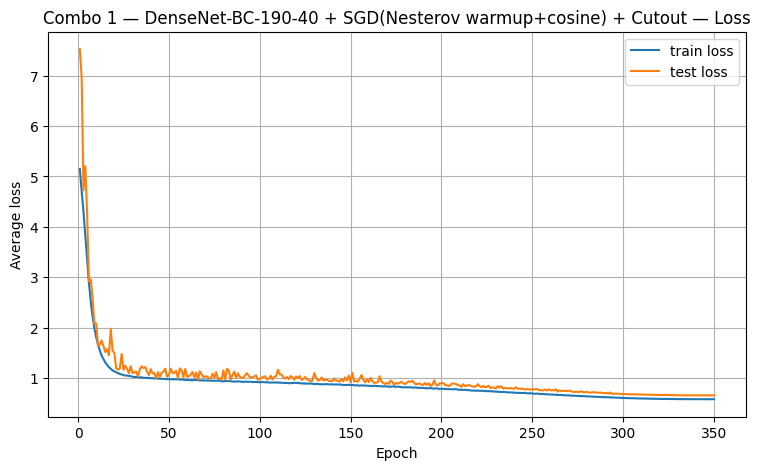

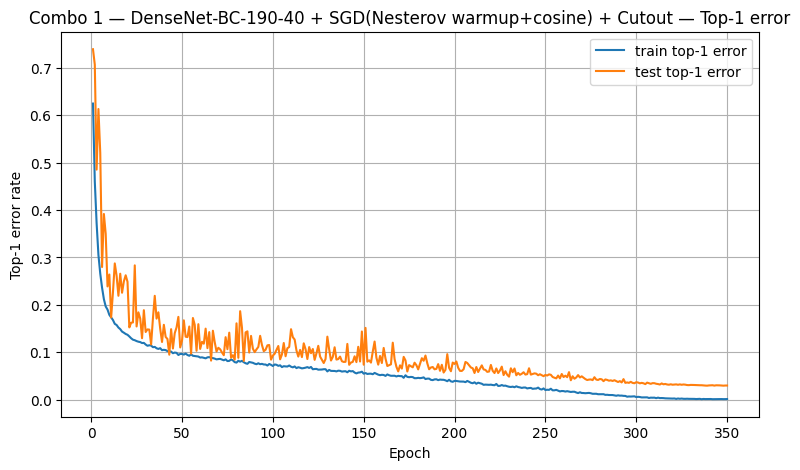

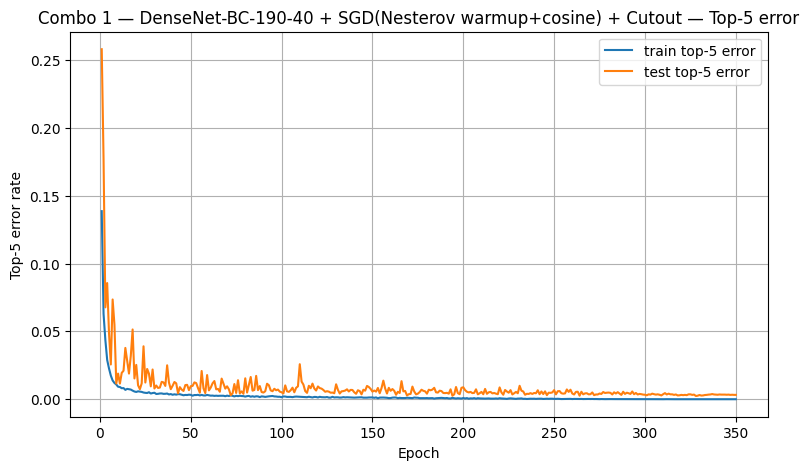


Per-epoch TEST metrics for: Combo 1 — DenseNet-BC-190-40 + SGD(Nesterov warmup+cosine) + Cutout


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.7390,0.2579,7.524815
1,2,0.7066,0.1773,6.947067
2,3,0.4852,0.0677,4.724749
3,4,0.6130,0.0856,5.206084
4,5,0.5207,0.0488,4.268128
...,...,...,...,...
345,346,0.0304,0.0034,0.656557
346,347,0.0300,0.0032,0.656009
347,348,0.0298,0.0033,0.656228
348,349,0.0301,0.0032,0.656642


✅ Saved per-epoch TEST metrics CSV: /content/drive/MyDrive/ST456_checkpoints/combo_1_densenet_bc_190_40_sgd_nesterov_warmup_cosine_cutout_test_metrics_per_epoch.csv


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.7390,0.2579,7.524815
1,2,0.7066,0.1773,6.947067
2,3,0.4852,0.0677,4.724749
3,4,0.6130,0.0856,5.206084
4,5,0.5207,0.0488,4.268128
...,...,...,...,...
345,346,0.0304,0.0034,0.656557
346,347,0.0300,0.0032,0.656009
347,348,0.0298,0.0033,0.656228
348,349,0.0301,0.0032,0.656642


In [ ]:
#P2: Run Combo 1 (DenseNet-BC)

cfg = configs[0]
print("\n==============================")
print(cfg.name)
print("==============================")
run = run_p2_config(cfg)
runs_by_name[cfg.name] = run
plot_p2_curves(run, cfg.name)

print_p2_test_errors_per_epoch(run)



Combo 2 — WRN-28-10 + SGD(Nesterov warmup+cosine) + Cutout
Epoch 1/350
352/352 - 121s - 343ms/step - loss: 6.3001 - top1_acc: 0.3927 - top5_acc: 0.8679 - val_loss: 6.8612 - val_top1_acc: 0.4028 - val_top5_acc: 0.8560
Epoch 2/350
352/352 - 13s - 36ms/step - loss: 5.3819 - top1_acc: 0.5821 - top5_acc: 0.9498 - val_loss: 5.3080 - val_top1_acc: 0.4912 - val_top5_acc: 0.9040
Epoch 3/350
352/352 - 13s - 36ms/step - loss: 4.3327 - top1_acc: 0.6536 - top5_acc: 0.9665 - val_loss: 4.1465 - val_top1_acc: 0.5802 - val_top5_acc: 0.9376
Epoch 4/350
352/352 - 13s - 36ms/step - loss: 3.2972 - top1_acc: 0.6942 - top5_acc: 0.9710 - val_loss: 3.0370 - val_top1_acc: 0.6212 - val_top5_acc: 0.9660
Epoch 5/350
352/352 - 13s - 36ms/step - loss: 2.4775 - top1_acc: 0.7095 - top5_acc: 0.9748 - val_loss: 2.6835 - val_top1_acc: 0.5846 - val_top5_acc: 0.9360
Epoch 6/350
352/352 - 13s - 36ms/step - loss: 1.9210 - top1_acc: 0.7277 - top5_acc: 0.9766 - val_loss: 2.0559 - val_top1_acc: 0.6382 - val_top5_acc: 0.9578
Ep

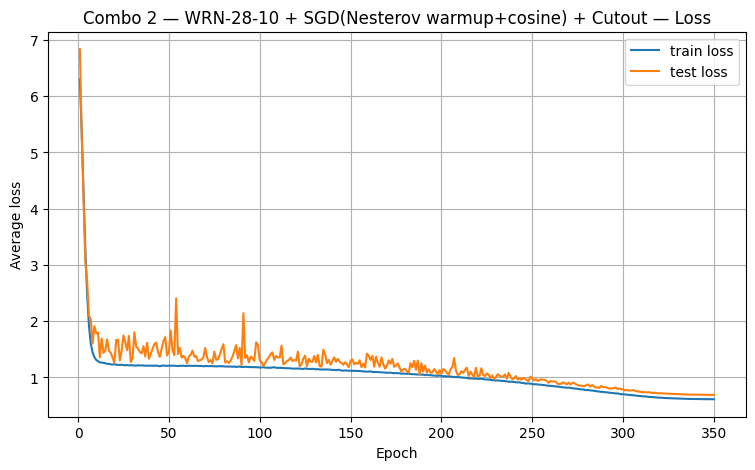

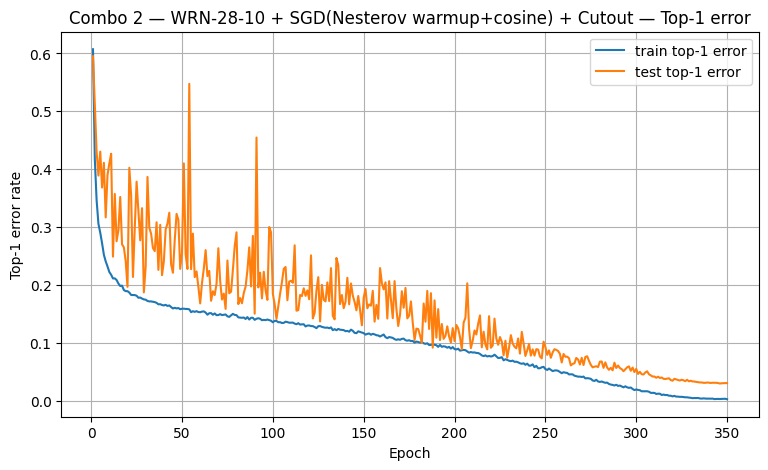

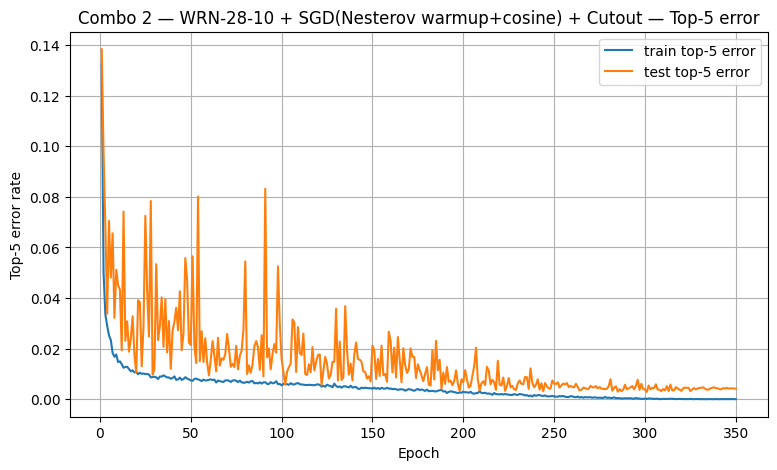

✅ Saved Combo 2 checkpoint for P3: /content/drive/MyDrive/ST456_checkpoints/p2_combo2_from_notebook.weights.h5

Per-epoch TEST metrics for: Combo 2 — WRN-28-10 + SGD(Nesterov warmup+cosine) + Cutout


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.5951,0.1384,6.835206
1,2,0.5128,0.0974,5.334912
2,3,0.4297,0.0681,4.189499
3,4,0.3891,0.0338,3.059448
4,5,0.4305,0.0705,2.728238
...,...,...,...,...
345,346,0.0301,0.0042,0.690940
346,347,0.0304,0.0043,0.691842
347,348,0.0307,0.0043,0.691688
348,349,0.0307,0.0042,0.691447


✅ Saved per-epoch TEST metrics CSV: /content/drive/MyDrive/ST456_checkpoints/combo_2_wrn_28_10_sgd_nesterov_warmup_cosine_cutout_test_metrics_per_epoch.csv


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.5951,0.1384,6.835206
1,2,0.5128,0.0974,5.334912
2,3,0.4297,0.0681,4.189499
3,4,0.3891,0.0338,3.059448
4,5,0.4305,0.0705,2.728238
...,...,...,...,...
345,346,0.0301,0.0042,0.690940
346,347,0.0304,0.0043,0.691842
347,348,0.0307,0.0043,0.691688
348,349,0.0307,0.0042,0.691447


In [ ]:
#P2: Run Combo 2

cfg = configs[1]
print("\n==============================")
print(cfg.name)
print("==============================")
run = run_p2_config(cfg)
runs_by_name[cfg.name] = run
plot_p2_curves(run, cfg.name)

#Auto-save the actual trained Combo 2 weights for strict P3 reuse ("network from P2")

_ckpt_dir = '/content/drive/MyDrive/ST456_checkpoints'
os.makedirs(_ckpt_dir, exist_ok=True)
_combo2_ckpt_path = os.path.join(_ckpt_dir, 'p2_combo2_from_notebook.weights.h5')
run["model"].save_weights(_combo2_ckpt_path)
print(f"✅ Saved Combo 2 checkpoint for P3: {_combo2_ckpt_path}")

print_p2_test_errors_per_epoch(run)



Combo 3 — EfficientNetB0 transfer + AdamW(cosine) + resize224
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/175
704/704 - 247s - 352ms/step - loss: 0.5813 - top1_acc: 0.8877 - top5_acc: 0.9935 - val_loss: 0.4369 - val_top1_acc: 0.9434 - val_top5_acc: 0.9982
Epoch 2/175
704/704 - 10s - 14ms/step - loss: 0.4509 - top1_acc: 0.9380 - top5_acc: 0.9987 - val_loss: 0.4184 - val_top1_acc: 0.9520 - val_top5_acc: 0.9984
Epoch 3/175
704/704 - 10s - 14ms/step - loss: 0.4165 - top1_acc: 0.9502 - top5_acc: 0.9993 - val_loss: 0.4211 - val_top1_acc: 0.9478 - val_top5_acc: 0.9986
Epoch 4/175
704/704 - 10s - 14ms/step - loss: 0.3909 - top1_acc: 0.9606 - top5_acc: 0.9996 - val_loss: 0.3937 - val_top1_acc: 0.9606 - val_top5_acc: 0.9996
Epoch 5/175
704/704 - 10s - 14ms/step - loss: 0.3740 - top1_acc: 0.9678 - top5_acc: 0.9997 - val_loss: 0.4085 - val_top1_acc: 0.9532 - val_top5_acc: 0.9990
Epoch 6/175
704/704 - 10s - 15ms/step - loss: 0.3627 - top1_acc: 0.9722 - top5_acc: 0.9998 - val_loss: 0

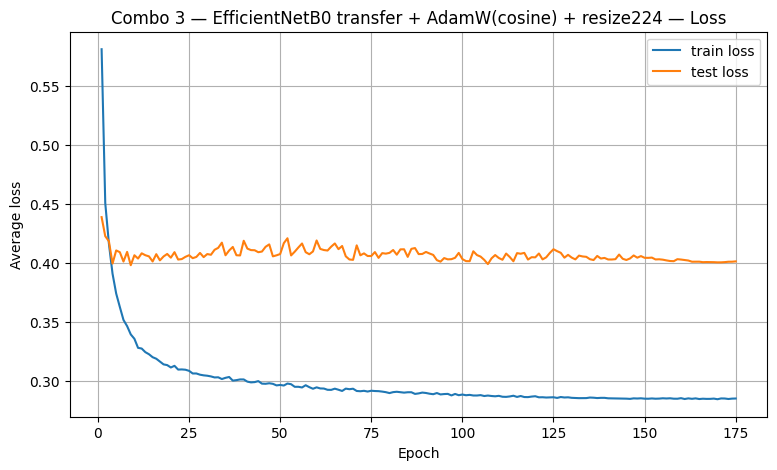

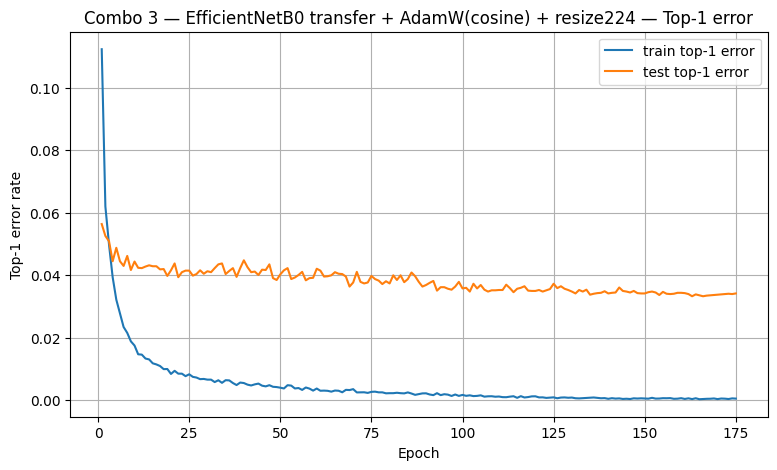

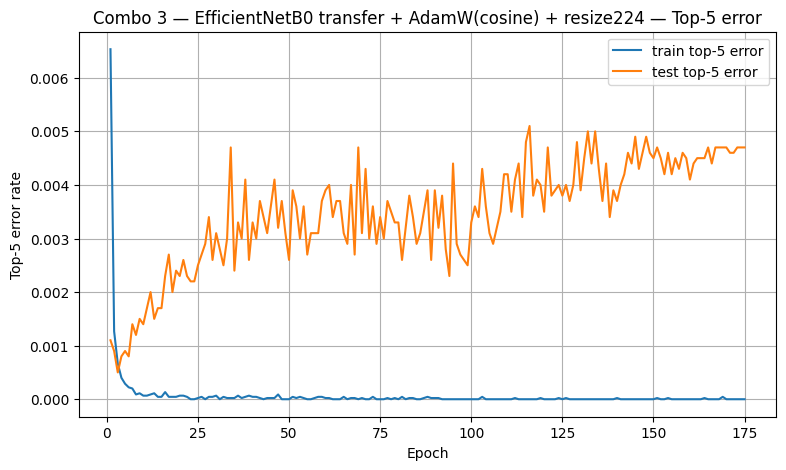


Per-epoch TEST metrics for: Combo 3 — EfficientNetB0 transfer + AdamW(cosine) + resize224


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.0564,0.0011,0.438871
1,2,0.0526,0.0009,0.422703
2,3,0.0509,0.0005,0.418414
3,4,0.0445,0.0008,0.399433
4,5,0.0488,0.0009,0.410603
...,...,...,...,...
170,171,0.0339,0.0046,0.400511
171,172,0.0340,0.0046,0.400701
172,173,0.0341,0.0047,0.401021
173,174,0.0340,0.0047,0.401049


✅ Saved per-epoch TEST metrics CSV: /content/drive/MyDrive/ST456_checkpoints/combo_3_efficientnetb0_transfer_adamw_cosine_resize224_test_metrics_per_epoch.csv


,epoch,test_top1_error,test_top5_error,test_loss
0,1,0.0564,0.0011,0.438871
1,2,0.0526,0.0009,0.422703
2,3,0.0509,0.0005,0.418414
3,4,0.0445,0.0008,0.399433
4,5,0.0488,0.0009,0.410603
...,...,...,...,...
170,171,0.0339,0.0046,0.400511
171,172,0.0340,0.0046,0.400701
172,173,0.0341,0.0047,0.401021
173,174,0.0340,0.0047,0.401049


In [ ]:
#P2: Run Combo 3 (transfer)

cfg = configs[2]
print("\n==============================")
print(cfg.name)
print("==============================")
run = run_p2_config(cfg)
runs_by_name[cfg.name] = run
plot_p2_curves(run, cfg.name)

print_p2_test_errors_per_epoch(run)


In [ ]:
#P3 CIFAR-10 dataset prep

#Fallback class names

if "CLASS_NAMES" not in globals():
    CLASS_NAMES = (
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck"
    )

#Build full CIFAR-10 train/val/test arrays expected by later P3 cells

p3_train_x = np.asarray(train_x)
p3_train_y = np.asarray(train_y).astype(np.int32).reshape(-1)
p3_val_x   = np.asarray(val_x)
p3_val_y   = np.asarray(val_y).astype(np.int32).reshape(-1)
p3_test_x  = np.asarray(test_x)
p3_test_y  = np.asarray(test_y).astype(np.int32).reshape(-1)

CLASS_NAMES_10 = tuple(CLASS_NAMES)

#Expected by P3

x_train_norm = p3_train_x
y_train_5    = p3_train_y
x_test_norm  = p3_test_x
y_test_5     = p3_test_y
CLASS_NAMES_5 = CLASS_NAMES_10

#Loss helper used by P3 attack/training cells

def sparse_ce_loss(y_true, logits, label_smoothing=0.0):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    logits = tf.cast(logits, tf.float32)
    ls = float(label_smoothing) if label_smoothing is not None else 0.0
    if ls > 0.0:
        depth = tf.shape(logits)[-1]
        y_onehot = tf.one_hot(y_true, depth=depth, dtype=tf.float32)
        loss = tf.keras.losses.categorical_crossentropy(
            y_onehot, logits, from_logits=True, label_smoothing=ls
        )
    else:
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, logits, from_logits=True)
    return tf.reduce_mean(loss)

#Dataset builders (used by later P3 cells)

def make_p3_train_ds(x, y, batch_size, use_augment=True):
    aug = augment_basic if (bool(use_augment) and "augment_basic" in globals()) else None
    return make_ds(
        x, y,
        batch_size=int(batch_size),
        training=True,
        augment_fn=aug,
        shuffle_buffer=min(len(x), 45000)
    )

def make_p3_eval_ds(x, y, batch_size):
    return make_ds(
        x, y,
        batch_size=int(batch_size),
        training=False,
        augment_fn=None
    )

print("  Train/Val/Test shapes:", p3_train_x.shape, p3_val_x.shape, p3_test_x.shape)
print("  Number of classes:", len(np.unique(p3_train_y)))
print("  Class names:", CLASS_NAMES_10)


  Train/Val/Test shapes: (45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)
  Number of classes: 10
  Class names: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [ ]:
#P3 cell 1: configuration (WRN-28-10 / P2 Combo 2 style)

from dataclasses import dataclass, asdict
from pathlib import Path
import json, os, time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

#Reproducibility (kept deterministic-ish but not forcing full determinism)

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

#Output root (Google Drive, as in the saved run)

P3_OUT_ROOT = Path("/content/drive/MyDrive") / "ST456_P3_outputs" / "p3_outputs_wrn_combo2"
print(f"✅ Google Drive detected. P3 outputs will be saved under: {P3_OUT_ROOT}")
P3_OUT_ROOT.mkdir(parents=True, exist_ok=True)

@dataclass
class P3Config:

    #Reporting metadata

    p2_model_variant_name: str = "combo2_wrn28x10_sgd_nesterov_warmup_cosine"
    report_title: str = "P3 Adversarial robustness — WRN-28-10 (P2 Combo 2, CIFAR-10)"

    #Model architecture (mirrors P2 Combo 2 design on full CIFAR-10)

    model_variant: str = "wrn28x10_p2style_cifar10"
    wrn_depth: int = 28
    wrn_widen_factor: int = 10
    wrn_dropout: float = 0.0       #matches P2 Combo 2 config
    weight_decay: float = 5e-4
    num_classes: int = 10

    #Dataset / runtime controls

    train_batch_size: int = 64
    eval_batch_size: int = 64
    shuffle_buffer: int = 10000
    max_train_samples: int | None = None
    max_test_samples: int | None = None

    #Natural baseline training (NO LONGER NEEDED GIVEN SAVED P2 WEIGHTS)

    natural_epochs: int = 12
    natural_lr: float = 0.05
    natural_momentum: float = 0.9
    natural_nesterov: bool = True
    label_smoothing: float = 0.05

    #Adversarial training stage (Madry-style PGD mini-batch generation)

    robust_epochs: int = 10
    robust_lr: float = 0.01
    robust_momentum: float = 0.9
    robust_nesterov: bool = True

    #Train-time attack for adversarial training

    train_attack_name: str = "pgd"
    train_eps: float = 8/255
    train_alpha: float = 2/255
    train_steps: int = 7
    train_random_start: bool = True

    #Evaluation attacks (for robustness curves + comparison tables)

    eval_eps_grid: tuple = (0.0, 1/255, 2/255, 4/255, 8/255, 12/255, 16/255)
    eval_attack_list: tuple = ("clean", "fgsm", "pgd")
    eval_pgd_steps: int = 20
    eval_pgd_alpha: float = 2/255
    eval_random_start: bool = True

    #Plotting / samples

    n_vis_examples: int = 8
    class_names: tuple | None = None

    #Loading of an already-trained P2 checkpoint

    p2_checkpoint_path: str | None = None
    require_p2_checkpoint_for_strict_brief: bool = True  #Making the P2 checkpoint loading strict to match the brief better

    #Saving

    save_plots: bool = True
    save_tables_csv: bool = True
    save_models: bool = True
    out_dir_name: str = "p3_wrn28x10_combo2_final"

P3 = P3Config()

#Auto-detect the Combo 2 checkpoint saved by the P2 Combo 2 run cell

_auto_ckpt_candidates = [
    "/content/drive/MyDrive/ST456_checkpoints/p2_combo2_from_notebook.weights.h5",
    "/content/ST456_checkpoints/p2_combo2_from_notebook.weights.h5",
]
if P3.p2_checkpoint_path is None:
    for _cand in _auto_ckpt_candidates:
        if os.path.exists(_cand):
            P3.p2_checkpoint_path = _cand
            print(f"✅ Auto-detected P2 Combo 2 checkpoint for P3: {_cand}")
            break

#Try to infer class names if P2 notebook defined them

if P3.class_names is None and "CLASS_NAMES_10" in globals():
    try:
        P3.class_names = tuple(CLASS_NAMES_10)
    except Exception:
        pass
elif P3.class_names is None and "CLASS_NAMES_5" in globals():  #Fallback
    try:
        P3.class_names = tuple(CLASS_NAMES_5)
    except Exception:
        pass

#P3 settings used later

P3.seed = GLOBAL_SEED

P3.natural_batch_size = int(P3.train_batch_size)
P3.robust_batch_size  = int(P3.train_batch_size)
P3.natural_label_smoothing = float(P3.label_smoothing)
P3.robust_label_smoothing  = float(P3.label_smoothing)

P3.attack_eps = float(P3.train_eps)
P3.attack_alpha = float(P3.train_alpha)
P3.attack_steps = int(P3.train_steps)
P3.attack_random_start = bool(P3.train_random_start)

P3.eval_adv_every_epoch = True
P3.natural_augment = True
P3.robust_augment = True
P3.eps_sweep = tuple(float(e) for e in P3.eval_eps_grid)
P3.pgd_eval_setups = (
    #8/255: vary both n_steps and step_size (core benchmark threat model)
    ("fgsm_8_1step_a8",   8/255, 8/255, 1),
    ("pgd_8_5step_a2",    8/255, 2/255, 5),
    ("pgd_8_10step_a2",   8/255, 2/255, 10),
    ("pgd_8_20step_a2",   8/255, 2/255, 20),
    ("pgd_8_20step_a1",   8/255, 1/255, 20),
    ("pgd_8_20step_a4",   8/255, 4/255, 20),
    #Stronger but still commonly-used upper-range
    ("pgd_16_10step_a2", 16/255, 2/255, 10),
    ("pgd_16_20step_a2", 16/255, 2/255, 20),
    ("pgd_16_20step_a4", 16/255, 4/255, 20),

    #Keep a named default driven by config

    ("pgd_eval_default", float(P3.attack_eps), float(P3.eval_pgd_alpha), int(P3.eval_pgd_steps)),
)

#Paths / class names expected in cells 5 and 6

P3_OUT = P3_OUT_ROOT / P3.out_dir_name
P3_OUT.mkdir(parents=True, exist_ok=True)
P3_CLASS_NAMES = tuple(P3.class_names) if P3.class_names is not None else tuple(f"class_{i}" for i in range(int(P3.num_classes)))

print("✅ P3 configuration loaded (WRN-28-10 / P2 Combo 2 style, CIFAR-10).")
print(json.dumps(asdict(P3), indent=2, default=str))
print(f"Output root: {P3_OUT_ROOT.resolve()}")


✅ Google Drive detected. P3 outputs will be saved under: /content/drive/MyDrive/ST456_P3_outputs/p3_outputs_wrn_combo2
✅ Auto-detected P2 Combo 2 checkpoint for P3: /content/drive/MyDrive/ST456_checkpoints/p2_combo2_from_notebook.weights.h5
✅ P3 configuration loaded (WRN-28-10 / P2 Combo 2 style, CIFAR-10).
{
  "p2_model_variant_name": "combo2_wrn28x10_sgd_nesterov_warmup_cosine",
  "report_title": "P3 Adversarial robustness \u2014 WRN-28-10 (P2 Combo 2, CIFAR-10)",
  "model_variant": "wrn28x10_p2style_cifar10",
  "wrn_depth": 28,
  "wrn_widen_factor": 10,
  "wrn_dropout": 0.0,
  "weight_decay": 0.0005,
  "num_classes": 10,
  "train_batch_size": 64,
  "eval_batch_size": 64,
  "shuffle_buffer": 10000,
  "max_train_samples": null,
  "max_test_samples": null,
  "natural_epochs": 12,
  "natural_lr": 0.05,
  "natural_momentum": 0.9,
  "natural_nesterov": true,
  "label_smoothing": 0.05,
  "robust_epochs": 10,
  "robust_lr": 0.01,
  "robust_momentum": 0.9,
  "robust_nesterov": true,
  "train

In [ ]:
#P3 cell 2: WRN-28-10 (P2 Combo 2 style) builder + optimizer helpers

def _wrn_basic_block_p3(x, out_filters, stride, dropout_rate, weight_decay):
    reg = keras.regularizers.l2(weight_decay)
    in_filters = int(x.shape[-1])

    # Pre-activation WideResNet block (matches P2 Combo 2 style)
    y = keras.layers.BatchNormalization()(x)
    y = keras.layers.ReLU()(y)
    y = keras.layers.Conv2D(
        out_filters, 3, strides=stride, padding="same",
        use_bias=False, kernel_regularizer=reg
    )(y)

    y = keras.layers.BatchNormalization()(y)
    y = keras.layers.ReLU()(y)
    if dropout_rate and dropout_rate > 0:
        y = keras.layers.Dropout(dropout_rate)(y)

    y = keras.layers.Conv2D(
        out_filters, 3, strides=1, padding="same",
        use_bias=False, kernel_regularizer=reg
    )(y)

    if stride != 1 or in_filters != out_filters:
        shortcut = keras.layers.Conv2D(
            out_filters, 1, strides=stride, padding="same",
            use_bias=False, kernel_regularizer=reg
        )(x)
    else:
        shortcut = x

    return keras.layers.Add()([y, shortcut])

def build_wrn_28_10_cifar10_p3(weight_decay=5e-4, dropout_rate=0.0, widen_factor=10, num_classes=10):
    #WideResNet depth=28 => N = (28 - 4) / 6 = 4 blocks per stage

    N = 4
    k = int(widen_factor)
    reg = keras.regularizers.l2(weight_decay)

    inputs = keras.Input(shape=(32, 32, 3))
    x = keras.layers.Conv2D(16, 3, padding="same", use_bias=False, kernel_regularizer=reg)(inputs)

    #Stage 1

    for _ in range(N):
        x = _wrn_basic_block_p3(x, 16 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    #Stage 2

    x = _wrn_basic_block_p3(x, 32 * k, stride=2, dropout_rate=dropout_rate, weight_decay=weight_decay)
    for _ in range(N - 1):
        x = _wrn_basic_block_p3(x, 32 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    #Stage 3

    x = _wrn_basic_block_p3(x, 64 * k, stride=2, dropout_rate=dropout_rate, weight_decay=weight_decay)
    for _ in range(N - 1):
        x = _wrn_basic_block_p3(x, 64 * k, stride=1, dropout_rate=dropout_rate, weight_decay=weight_decay)

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    logits = keras.layers.Dense(num_classes)(x)

    return keras.Model(inputs, logits, name="WRN_28_10_CIFAR10_P3")

def make_p3_model(cfg: P3Config):
    if cfg.model_variant != "wrn28x10_p2style_cifar10":
        raise ValueError(f"Unsupported model_variant for this final P3 append: {cfg.model_variant}")

    model = build_wrn_28_10_cifar10_p3(
        weight_decay=cfg.weight_decay,
        dropout_rate=cfg.wrn_dropout,
        widen_factor=cfg.wrn_widen_factor,
        num_classes=int(getattr(cfg, "num_classes", 10)),
    )
    return model

def maybe_load_p2_checkpoint(model, cfg: P3Config):
    ckpt = str(cfg.p2_checkpoint_path)
    model.load_weights(ckpt)
    print(f"✅ Loaded checkpoint weights from: {ckpt}")
    return True

def make_sgd_optimizer(lr, momentum=0.9, nesterov=True):
    return keras.optimizers.SGD(
        learning_rate=lr,
        momentum=momentum,
        nesterov=nesterov
    )

#Sanity check the build

_tmp_model = make_p3_model(P3)
_tmp_model.build((None, 32, 32, 3))
print(_tmp_model.name)
print(f"Trainable params: {int(np.sum([np.prod(v.shape) for v in _tmp_model.trainable_weights])):,}")
del _tmp_model


WRN_28_10_CIFAR10_P3
Trainable params: 36,479,194


In [ ]:
#P3 cell 3: PGD attack (L_inf) in normalized-input space

_CIFAR_MEAN_TF = tf.reshape(tf.convert_to_tensor(CIFAR_MEAN, dtype=tf.float32), (1, 1, 1, 3))
_CIFAR_STD_TF  = tf.reshape(tf.convert_to_tensor(CIFAR_STD,  dtype=tf.float32), (1, 1, 1, 3))

#Adversarial bounds (eps, alpha) defined in pixel space must be converted into normalized space.

_P3_NORM_MIN = (0.0 - _CIFAR_MEAN_TF) / _CIFAR_STD_TF
_P3_NORM_MAX = (1.0 - _CIFAR_MEAN_TF) / _CIFAR_STD_TF

def _clip_valid_normalized_image(x):
    return tf.clip_by_value(x, _P3_NORM_MIN, _P3_NORM_MAX)

def _eps_alpha_pixel_to_normalized(eps_pixel, alpha_pixel):
    eps = tf.constant(float(eps_pixel), tf.float32) / _CIFAR_STD_TF
    alpha = tf.constant(float(alpha_pixel), tf.float32) / _CIFAR_STD_TF
    return eps, alpha

def pgd_linf_attack_tf(
    model,
    x,
    y,
    eps_pixel=8.0/255.0,
    alpha_pixel=2.0/255.0,
    steps=5,
    random_start=True,
    label_smoothing=0.0,
):

    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.cast(tf.reshape(y, [-1]), tf.int32)
    eps, alpha = _eps_alpha_pixel_to_normalized(eps_pixel, alpha_pixel)

    x0 = x
    x_min = tf.maximum(x0 - eps, _P3_NORM_MIN)
    x_max = tf.minimum(x0 + eps, _P3_NORM_MAX)

    if random_start:
        x_adv = x0 + tf.random.uniform(tf.shape(x0), minval=-1.0, maxval=1.0, dtype=tf.float32) * eps
        x_adv = tf.clip_by_value(x_adv, x_min, x_max)
        x_adv = _clip_valid_normalized_image(x_adv)
    else:
        x_adv = tf.identity(x0)

    for _ in range(int(steps)):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            preds = model(x_adv, training=False)
            loss = sparse_ce_loss(y, preds, label_smoothing=label_smoothing)
        grad = tape.gradient(loss, x_adv)
        x_adv = x_adv + alpha * tf.sign(grad)
        x_adv = tf.clip_by_value(x_adv, x_min, x_max)
        x_adv = _clip_valid_normalized_image(x_adv)

    return tf.stop_gradient(x_adv)

def batch_clean_metrics(model, x, y, label_smoothing=0.0):
    preds = model(x, training=False)
    loss = sparse_ce_loss(y, preds, label_smoothing=label_smoothing)
    acc  = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(preds, axis=1, output_type=tf.int32),
                                           tf.cast(tf.reshape(y, [-1]), tf.int32)), tf.float32))
    return loss, acc

def batch_adv_metrics(model, x, y, eps_pixel, alpha_pixel, steps, random_start=True, label_smoothing=0.0):
    x_adv = pgd_linf_attack_tf(
        model, x, y,
        eps_pixel=eps_pixel,
        alpha_pixel=alpha_pixel,
        steps=steps,
        random_start=random_start,
        label_smoothing=label_smoothing,
    )
    preds = model(x_adv, training=False)
    loss = sparse_ce_loss(y, preds, label_smoothing=label_smoothing)
    acc  = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(preds, axis=1, output_type=tf.int32),
                                           tf.cast(tf.reshape(y, [-1]), tf.int32)), tf.float32))
    return loss, acc, x_adv


In [ ]:
#P3 cell 4: custom train/eval loops (natural and robust) + logging

def _epoch_reduce(metric_sums, n_batches):
    out = {k: (float(v) / max(1, n_batches)) for k, v in metric_sums.items()}
    return out

def evaluate_dataset_clean(model, ds, label_smoothing=0.0):
    sums = {"loss": 0.0, "acc": 0.0}
    n_batches = 0
    for xb, yb in ds:
        loss, acc = batch_clean_metrics(model, xb, yb, label_smoothing=label_smoothing)
        sums["loss"] += float(loss.numpy())
        sums["acc"]  += float(acc.numpy())
        n_batches += 1
    return _epoch_reduce(sums, n_batches)

def evaluate_dataset_adv(model, ds, eps_pixel, alpha_pixel, steps, random_start=True, label_smoothing=0.0):
    sums = {"loss": 0.0, "acc": 0.0}
    n_batches = 0
    for xb, yb in ds:
        loss, acc, _ = batch_adv_metrics(
            model, xb, yb,
            eps_pixel=eps_pixel, alpha_pixel=alpha_pixel, steps=steps,
            random_start=random_start,
            label_smoothing=label_smoothing,
        )
        sums["loss"] += float(loss.numpy())
        sums["acc"]  += float(acc.numpy())
        n_batches += 1
    return _epoch_reduce(sums, n_batches)

def train_one_epoch_natural(model, ds, optimizer, label_smoothing=0.0):
    sums = {"loss": 0.0, "acc": 0.0}
    n_batches = 0
    for step, (xb, yb) in enumerate(ds):
        with tf.GradientTape() as tape:
            preds = model(xb, training=True)
            loss = sparse_ce_loss(yb, preds, label_smoothing=label_smoothing)
            # include regularization losses (important for WRN with L2 weight decay)
            if model.losses:
                loss = loss + tf.add_n(model.losses)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        acc = tf.reduce_mean(tf.cast(tf.equal(
            tf.argmax(preds, axis=1, output_type=tf.int32),
            tf.cast(tf.reshape(yb, [-1]), tf.int32)), tf.float32))

        sums["loss"] += float(loss.numpy())
        sums["acc"]  += float(acc.numpy())
        n_batches += 1
    return _epoch_reduce(sums, n_batches)

def train_one_epoch_robust(model, ds, optimizer, attack_cfg, label_smoothing=0.0):
    sums = {"loss": 0.0, "acc": 0.0, "clean_acc": 0.0}
    n_batches = 0
    for step, (xb, yb) in enumerate(ds):
        # Generate adversarial examples using current model snapshot (standard adversarial training)
        xb_adv = pgd_linf_attack_tf(
            model, xb, yb,
            eps_pixel=attack_cfg["eps_pixel"],
            alpha_pixel=attack_cfg["alpha_pixel"],
            steps=attack_cfg["steps"],
            random_start=attack_cfg.get("random_start", True),
            label_smoothing=label_smoothing,
        )

        with tf.GradientTape() as tape:
            preds_adv = model(xb_adv, training=True)
            loss = sparse_ce_loss(yb, preds_adv, label_smoothing=label_smoothing)
            if model.losses:
                loss = loss + tf.add_n(model.losses)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        adv_acc = tf.reduce_mean(tf.cast(tf.equal(
            tf.argmax(preds_adv, axis=1, output_type=tf.int32),
            tf.cast(tf.reshape(yb, [-1]), tf.int32)), tf.float32))

        preds_clean = model(xb, training=False)
        clean_acc = tf.reduce_mean(tf.cast(tf.equal(
            tf.argmax(preds_clean, axis=1, output_type=tf.int32),
            tf.cast(tf.reshape(yb, [-1]), tf.int32)), tf.float32))

        sums["loss"] += float(loss.numpy())
        sums["acc"]  += float(adv_acc.numpy())
        sums["clean_acc"] += float(clean_acc.numpy())
        n_batches += 1

    return _epoch_reduce(sums, n_batches)

def fit_natural_stage(model, cfg: P3Config):
    train_ds = make_p3_train_ds(p3_train_x, p3_train_y, cfg.natural_batch_size, cfg.natural_augment)
    val_ds   = make_p3_eval_ds(p3_val_x, p3_val_y, cfg.natural_batch_size)
    test_ds  = make_p3_eval_ds(p3_test_x, p3_test_y, cfg.natural_batch_size)

    optimizer = make_sgd_optimizer(cfg.natural_lr, cfg.natural_momentum)
    rows = []
    print(f"\n[P3] Natural pre-training ({cfg.natural_epochs} epochs target)")
    for epoch in range(1, cfg.natural_epochs + 1):
        t0 = time.time()
        train_m = train_one_epoch_natural(model, train_ds, optimizer, cfg.natural_label_smoothing)
        val_m   = evaluate_dataset_clean(model, val_ds,   cfg.natural_label_smoothing)
        test_m  = evaluate_dataset_clean(model, test_ds,  cfg.natural_label_smoothing)

        row = {
            "stage": "natural",
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_acc": train_m["acc"],
            "val_clean_loss": val_m["loss"],
            "val_clean_acc": val_m["acc"],
            "test_clean_loss": test_m["loss"],
            "test_clean_acc": test_m["acc"],
            "epoch_time_sec": time.time() - t0,
        }
        if cfg.eval_adv_every_epoch:
            test_adv = evaluate_dataset_adv(
                model, test_ds,
                eps_pixel=cfg.attack_eps, alpha_pixel=cfg.attack_alpha, steps=cfg.attack_steps,
                random_start=cfg.attack_random_start,
                label_smoothing=cfg.natural_label_smoothing,
            )
            row["test_adv_loss_eps8"] = test_adv["loss"]
            row["test_adv_acc_eps8"]  = test_adv["acc"]

        rows.append(row)
        print(
            f"  Epoch {epoch:02d}/{cfg.natural_epochs} | "
            f"train acc={row['train_acc']:.4f} | val clean acc={row['val_clean_acc']:.4f} | "
            f"test clean acc={row['test_clean_acc']:.4f}" +
            (f" | test adv@8/255 acc={row['test_adv_acc_eps8']:.4f}" if cfg.eval_adv_every_epoch else "") +
            f" | {row['epoch_time_sec']:.1f}s"
        )

    return pd.DataFrame(rows)

def fit_robust_stage(model, cfg: P3Config):
    train_ds = make_p3_train_ds(p3_train_x, p3_train_y, cfg.robust_batch_size, cfg.robust_augment)
    val_ds   = make_p3_eval_ds(p3_val_x, p3_val_y, cfg.robust_batch_size)
    test_ds  = make_p3_eval_ds(p3_test_x, p3_test_y, cfg.robust_batch_size)

    optimizer = make_sgd_optimizer(cfg.robust_lr, cfg.robust_momentum)
    atk = {
        "eps_pixel": cfg.attack_eps,
        "alpha_pixel": cfg.attack_alpha,
        "steps": cfg.attack_steps,
        "random_start": cfg.attack_random_start,
    }

    rows = []
    print("\n[P3] Robust fine-tuning (adversarial training)")
    for epoch in range(1, cfg.robust_epochs + 1):
        t0 = time.time()
        train_m = train_one_epoch_robust(model, train_ds, optimizer, atk, cfg.robust_label_smoothing)
        val_clean = evaluate_dataset_clean(model, val_ds, cfg.robust_label_smoothing)
        val_adv   = evaluate_dataset_adv(
            model, val_ds,
            eps_pixel=cfg.attack_eps, alpha_pixel=cfg.attack_alpha, steps=cfg.attack_steps,
            random_start=cfg.attack_random_start,
            label_smoothing=cfg.robust_label_smoothing,
        )
        test_clean = evaluate_dataset_clean(model, test_ds, cfg.robust_label_smoothing)
        test_adv   = evaluate_dataset_adv(
            model, test_ds,
            eps_pixel=cfg.attack_eps, alpha_pixel=cfg.attack_alpha, steps=cfg.attack_steps,
            random_start=cfg.attack_random_start,
            label_smoothing=cfg.robust_label_smoothing,
        )

        row = {
            "stage": "robust",
            "epoch": epoch,
            "train_adv_loss": train_m["loss"],
            "train_adv_acc": train_m["acc"],
            "train_clean_acc": train_m["clean_acc"],
            "val_clean_loss": val_clean["loss"],
            "val_clean_acc": val_clean["acc"],
            "val_adv_loss_eps8": val_adv["loss"],
            "val_adv_acc_eps8": val_adv["acc"],
            "test_clean_loss": test_clean["loss"],
            "test_clean_acc": test_clean["acc"],
            "test_adv_loss_eps8": test_adv["loss"],
            "test_adv_acc_eps8": test_adv["acc"],
            "epoch_time_sec": time.time() - t0,
        }
        rows.append(row)
        print(
            f"  Epoch {epoch:02d}/{cfg.robust_epochs} | "
            f"train adv acc={row['train_adv_acc']:.4f} | train clean acc={row['train_clean_acc']:.4f} | "
            f"test clean acc={row['test_clean_acc']:.4f} | test adv@8/255 acc={row['test_adv_acc_eps8']:.4f} | "
            f"{row['epoch_time_sec']:.1f}s"
        )

    return pd.DataFrame(rows)

def evaluate_attack_suite(model, cfg: P3Config, ds=None, split_name="test", label_smoothing=0.0):
    if ds is None:
        ds = make_p3_eval_ds(p3_test_x, p3_test_y, max(cfg.natural_batch_size, cfg.robust_batch_size))
    rows = []
    clean = evaluate_dataset_clean(model, ds, label_smoothing=label_smoothing)
    rows.append({
        "split": split_name, "attack": "clean", "eps": 0.0, "alpha": 0.0, "steps": 0,
        "loss": clean["loss"], "acc": clean["acc"]
    })

    #Epsilon sweep (PGD with default steps)

    for eps in cfg.eps_sweep:
        if float(eps) == 0.0:
            continue
        adv = evaluate_dataset_adv(
            model, ds,
            eps_pixel=float(eps),
            alpha_pixel=min(float(eps), cfg.attack_alpha),
            steps=max(1, cfg.attack_steps),
            random_start=True,
            label_smoothing=label_smoothing,
        )
        rows.append({
            "split": split_name, "attack": "pgd_eps_sweep",
            "eps": float(eps), "alpha": min(float(eps), cfg.attack_alpha), "steps": max(1, cfg.attack_steps),
            "loss": adv["loss"], "acc": adv["acc"]
        })

    #PGD setup sweep

    for name, eps, alpha, steps in cfg.pgd_eval_setups:
        adv = evaluate_dataset_adv(
            model, ds,
            eps_pixel=float(eps),
            alpha_pixel=float(alpha),
            steps=int(steps),
            random_start=True,
            label_smoothing=label_smoothing,
        )
        rows.append({
            "split": split_name, "attack": str(name),
            "eps": float(eps), "alpha": float(alpha), "steps": int(steps),
            "loss": adv["loss"], "acc": adv["acc"]
        })
    return pd.DataFrame(rows)

def plot_p3_training_curves(df_natural, df_robust, save_path=None):
    plt.figure(figsize=(10, 6))
    plt.plot(df_natural["epoch"], df_natural["test_clean_acc"], label="Natural stage: test clean acc")
    if "test_adv_acc_eps8" in df_natural.columns:
        plt.plot(df_natural["epoch"], df_natural["test_adv_acc_eps8"], label="Natural stage: test adv@8/255 acc")
    x2 = df_robust["epoch"] + (df_natural["epoch"].max() if len(df_natural) else 0)
    plt.plot(x2, df_robust["test_clean_acc"], label="Robust stage: test clean acc")
    plt.plot(x2, df_robust["test_adv_acc_eps8"], label="Robust stage: test adv@8/255 acc")
    plt.axvline(df_natural["epoch"].max(), linestyle="--")
    plt.xlabel("Epoch (continuous across stages)")
    plt.ylabel("Accuracy")
    plt.title("P3: Clean vs Adversarial Test Accuracy (Before/After Robust Training)")
    plt.legend()
    plt.grid(True, alpha=0.25)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=180)
    plt.show()


Model: "WRN_28_10_CIFAR10_P3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     23,040 │ re_lu[0][0]       │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        640 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    230,400 │ re_lu_1[0][0]     │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,560 │ conv2d[0][0]      │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 160)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        640 │ add[0][0]         │
│ (BatchNormalizatio… │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    230,400 │ re_lu_2[0][0]     │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        640 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    230,400 │ re_lu_3[0][0]     │
│                     │ 160)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_5[0][0], 

 Total params: 36,497,146 (139.23 MB)

 Trainable params: 36,479,194 (139.16 MB)

 Non-trainable params: 17,952 (70.12 KB)

✅ Loaded checkpoint weights from: /content/drive/MyDrive/ST456_checkpoints/p2_combo2_from_notebook.weights.h5
✅ Using loaded P2 checkpoint as the pre-robust baseline (no extra natural-stage re-training).

Pre-robust attack suite:
              split            attack       eps     alpha  steps      loss  \
0   test_pre_robust             clean  0.000000  0.000000      0  0.391936   
1   test_pre_robust   fgsm_8_1step_a8  0.031373  0.031373      1  1.627296   
2   test_pre_robust  pgd_16_10step_a2  0.062745  0.007843     10  6.006425   
3   test_pre_robust  pgd_16_20step_a2  0.062745  0.007843     20  7.767933   
4   test_pre_robust  pgd_16_20step_a4  0.062745  0.015686     20  7.901817   
5   test_pre_robust   pgd_8_10step_a2  0.031373  0.007843     10  4.784896   
6   test_pre_robust   pgd_8_20step_a1  0.031373  0.003922     20  5.606667   
7   test_pre_robust   pgd_8_20step_a2  0.031373  0.007843     20  6.185887   
8   test_pre_robust   pgd_8_20step_a4  0.031373  0.015686     20  5.

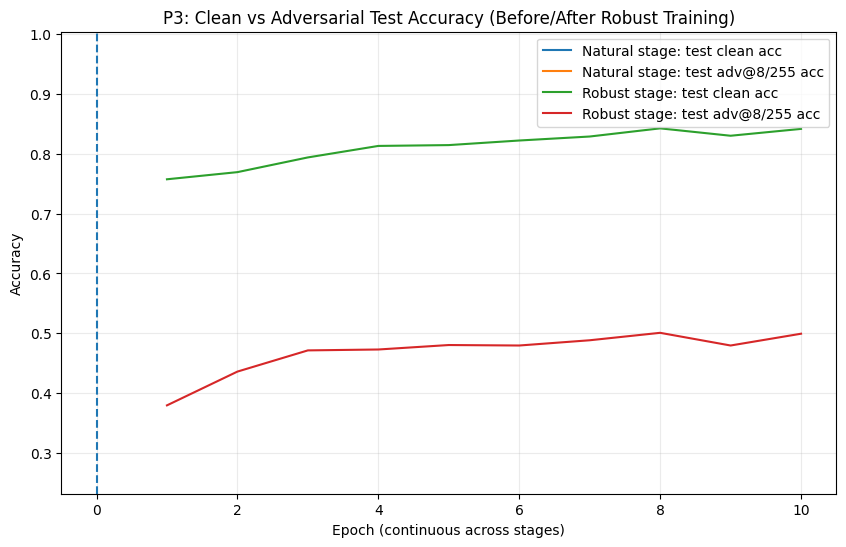


Saved outputs in: /content/drive/MyDrive/ST456_P3_outputs/p3_outputs_wrn_combo2/p3_wrn28x10_combo2_final
Files: ['p3_attack_suite_comparison.csv', 'p3_attack_suite_post_robust.csv', 'p3_attack_suite_pre_robust.csv', 'p3_clean_vs_adv_accuracy_curve.png', 'p3_model_after_natural.keras', 'p3_model_after_natural.weights.h5', 'p3_model_after_robust.keras', 'p3_model_after_robust.weights.h5', 'p3_natural_stage_log.csv', 'p3_robust_stage_log.csv', 'p3_summary.json']


In [ ]:
#P3 cell 5: run P3 end-to-end: natural train -> attack eval -> robust train -> attack eval

tf.keras.backend.clear_session()

#Build and summarise model (P2 Combo 2 WRN-28-10 family on full CIFAR-10)

p3_model = make_p3_model(P3)
p3_model.build((None, 32, 32, 3))
p3_model.summary()

#Stage A: baseline model (prefer loading the actual P2 network if checkpoint is provided)

_loaded_p2_ckpt = maybe_load_p2_checkpoint(p3_model, P3)

if _loaded_p2_ckpt:

    #Baseline row for plots

    _val_ds  = make_p3_eval_ds(p3_val_x,  p3_val_y,  P3.natural_batch_size)
    _test_ds = make_p3_eval_ds(p3_test_x, p3_test_y, P3.natural_batch_size)

    _val_clean  = evaluate_dataset_clean(p3_model, _val_ds,  P3.natural_label_smoothing)
    _test_clean = evaluate_dataset_clean(p3_model, _test_ds, P3.natural_label_smoothing)
    _test_adv   = evaluate_dataset_adv(
        p3_model, _test_ds,
        eps_pixel=P3.attack_eps, alpha_pixel=P3.attack_alpha, steps=P3.attack_steps,
        random_start=P3.attack_random_start,
        label_smoothing=P3.natural_label_smoothing,
    )
    p3_natural_log = pd.DataFrame([{
        "stage": "natural_loaded_from_p2",
        "epoch": 0,
        "train_loss": np.nan,
        "train_acc": np.nan,
        "val_clean_loss": _val_clean["loss"],
        "val_clean_acc": _val_clean["acc"],
        "test_clean_loss": _test_clean["loss"],
        "test_clean_acc": _test_clean["acc"],
        "test_adv_loss_eps8": _test_adv["loss"],
        "test_adv_acc_eps8": _test_adv["acc"],
        "epoch_time_sec": 0.0,
    }])
    print("✅ Using loaded P2 checkpoint as the pre-robust baseline (no extra natural-stage re-training).")
else:
    p3_natural_log = fit_natural_stage(p3_model, P3)

p3_natural_log.to_csv(P3_OUT / "p3_natural_stage_log.csv", index=False)

if P3.save_models:
    p3_model.save(P3_OUT / "p3_model_after_natural.keras")
    p3_model.save_weights(P3_OUT / "p3_model_after_natural.weights.h5")

#Snapshot baseline model before robust fine-tuning

p3_model_baseline = make_p3_model(P3)
_ = p3_model_baseline(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)
p3_model_baseline.set_weights(p3_model.get_weights())

#Pre-robust evaluation suite (baseline)

p3_pre_suite = evaluate_attack_suite(
    p3_model_baseline,
    P3,
    ds=make_p3_eval_ds(p3_test_x, p3_test_y, max(P3.natural_batch_size, P3.robust_batch_size)),
    split_name="test_pre_robust",
    label_smoothing=P3.natural_label_smoothing,
)
p3_pre_suite.to_csv(P3_OUT / "p3_attack_suite_pre_robust.csv", index=False)
print("\nPre-robust attack suite:")
print(p3_pre_suite.sort_values(["attack", "eps", "steps"]).reset_index(drop=True))

#Stage B: robust fine-tuning (adversarial training)

p3_robust_log = fit_robust_stage(p3_model, P3)
p3_robust_log.to_csv(P3_OUT / "p3_robust_stage_log.csv", index=False)

if P3.save_models:
    p3_model.save(P3_OUT / "p3_model_after_robust.keras")
    p3_model.save_weights(P3_OUT / "p3_model_after_robust.weights.h5")

#Post-robust evaluation suite

p3_post_suite = evaluate_attack_suite(
    p3_model,
    P3,
    ds=make_p3_eval_ds(p3_test_x, p3_test_y, max(P3.natural_batch_size, P3.robust_batch_size)),
    split_name="test_post_robust",
    label_smoothing=P3.robust_label_smoothing,
)
p3_post_suite.to_csv(P3_OUT / "p3_attack_suite_post_robust.csv", index=False)
print("\nPost-robust attack suite:")
print(p3_post_suite.sort_values(["attack", "eps", "steps"]).reset_index(drop=True))

#Combined comparison table

p3_compare = (
    p3_pre_suite.rename(columns={"loss": "pre_loss", "acc": "pre_acc"})
    .merge(
        p3_post_suite.rename(columns={"loss": "post_loss", "acc": "post_acc"}),
        on=["attack", "eps", "alpha", "steps"],
        how="outer"
    )
    .sort_values(["attack", "eps", "steps"])
    .reset_index(drop=True)
)
p3_compare["delta_acc_post_minus_pre"] = p3_compare["post_acc"] - p3_compare["pre_acc"]
p3_compare["delta_loss_post_minus_pre"] = p3_compare["post_loss"] - p3_compare["pre_loss"]
p3_compare.to_csv(P3_OUT / "p3_attack_suite_comparison.csv", index=False)

print("\nComparison (post - pre):")
print(p3_compare)

plot_p3_training_curves(
    p3_natural_log, p3_robust_log,
    save_path=P3_OUT / "p3_clean_vs_adv_accuracy_curve.png"
)

#Save a compact summary JSON for the report

p3_summary = {
    "dataset": "CIFAR-10",
    "classes": P3_CLASS_NAMES,
    "used_p2_checkpoint": bool(_loaded_p2_ckpt),
    "p2_checkpoint_path": str(P3.p2_checkpoint_path) if P3.p2_checkpoint_path else None,
    "natural_epochs": int(P3.natural_epochs),
    "robust_epochs": int(P3.robust_epochs),
    "attack_train_eval_default": {
        "eps": float(P3.attack_eps),
        "alpha": float(P3.attack_alpha),
        "steps": int(P3.attack_steps),
        "random_start": bool(P3.attack_random_start),
    },
    "natural_final_test_clean_acc": float(p3_natural_log.iloc[-1]["test_clean_acc"]),
    "natural_final_test_adv_acc_eps8": float(p3_natural_log.iloc[-1].get("test_adv_acc_eps8", np.nan)),
    "robust_final_test_clean_acc": float(p3_robust_log.iloc[-1]["test_clean_acc"]),
    "robust_final_test_adv_acc_eps8": float(p3_robust_log.iloc[-1]["test_adv_acc_eps8"]),
}
with open(P3_OUT / "p3_summary.json", "w") as f:
    json.dump(p3_summary, f, indent=2)

print("\nSaved outputs in:", P3_OUT.resolve())
if str(P3_OUT.resolve()).startswith("/content/") and not str(P3_OUT.resolve()).startswith("/content/drive/"):
    print("These outputs are in local Colab runtime storage and may be deleted when the runtime disconnects.")
    print("   Copy them to Google Drive before ending the session.")
print("Files:", sorted([p.name for p in P3_OUT.iterdir()]))


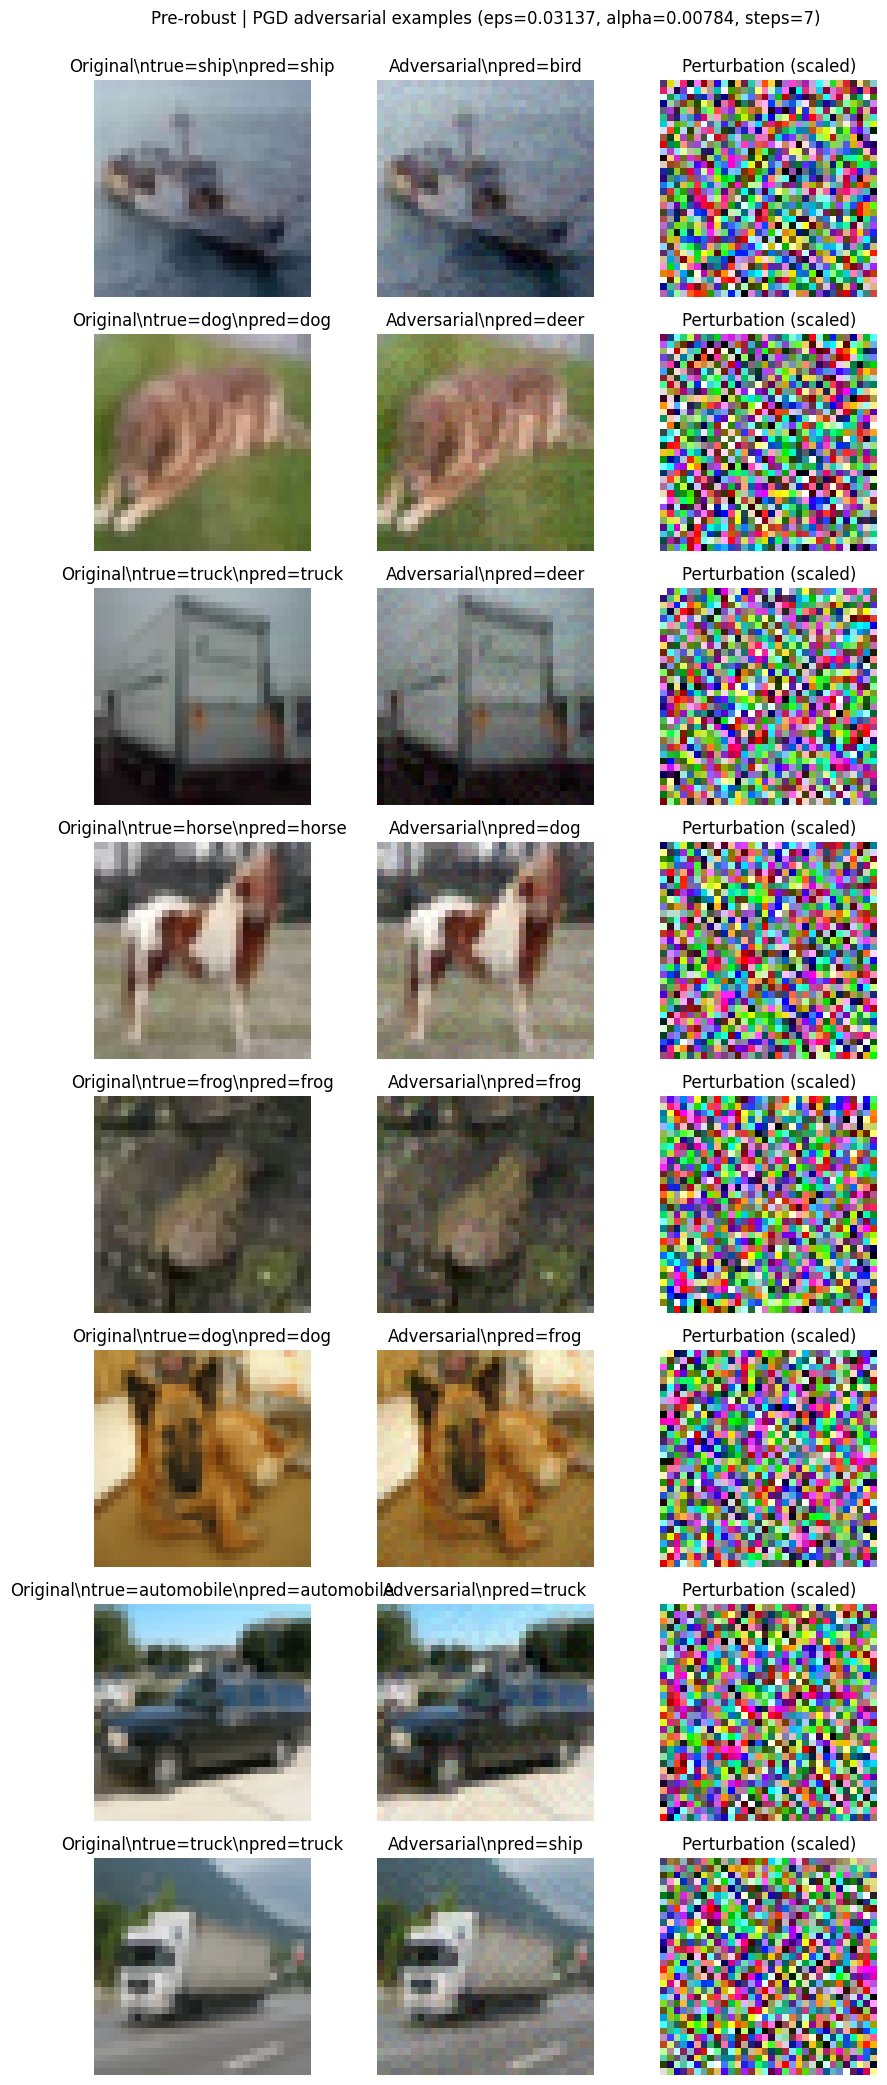

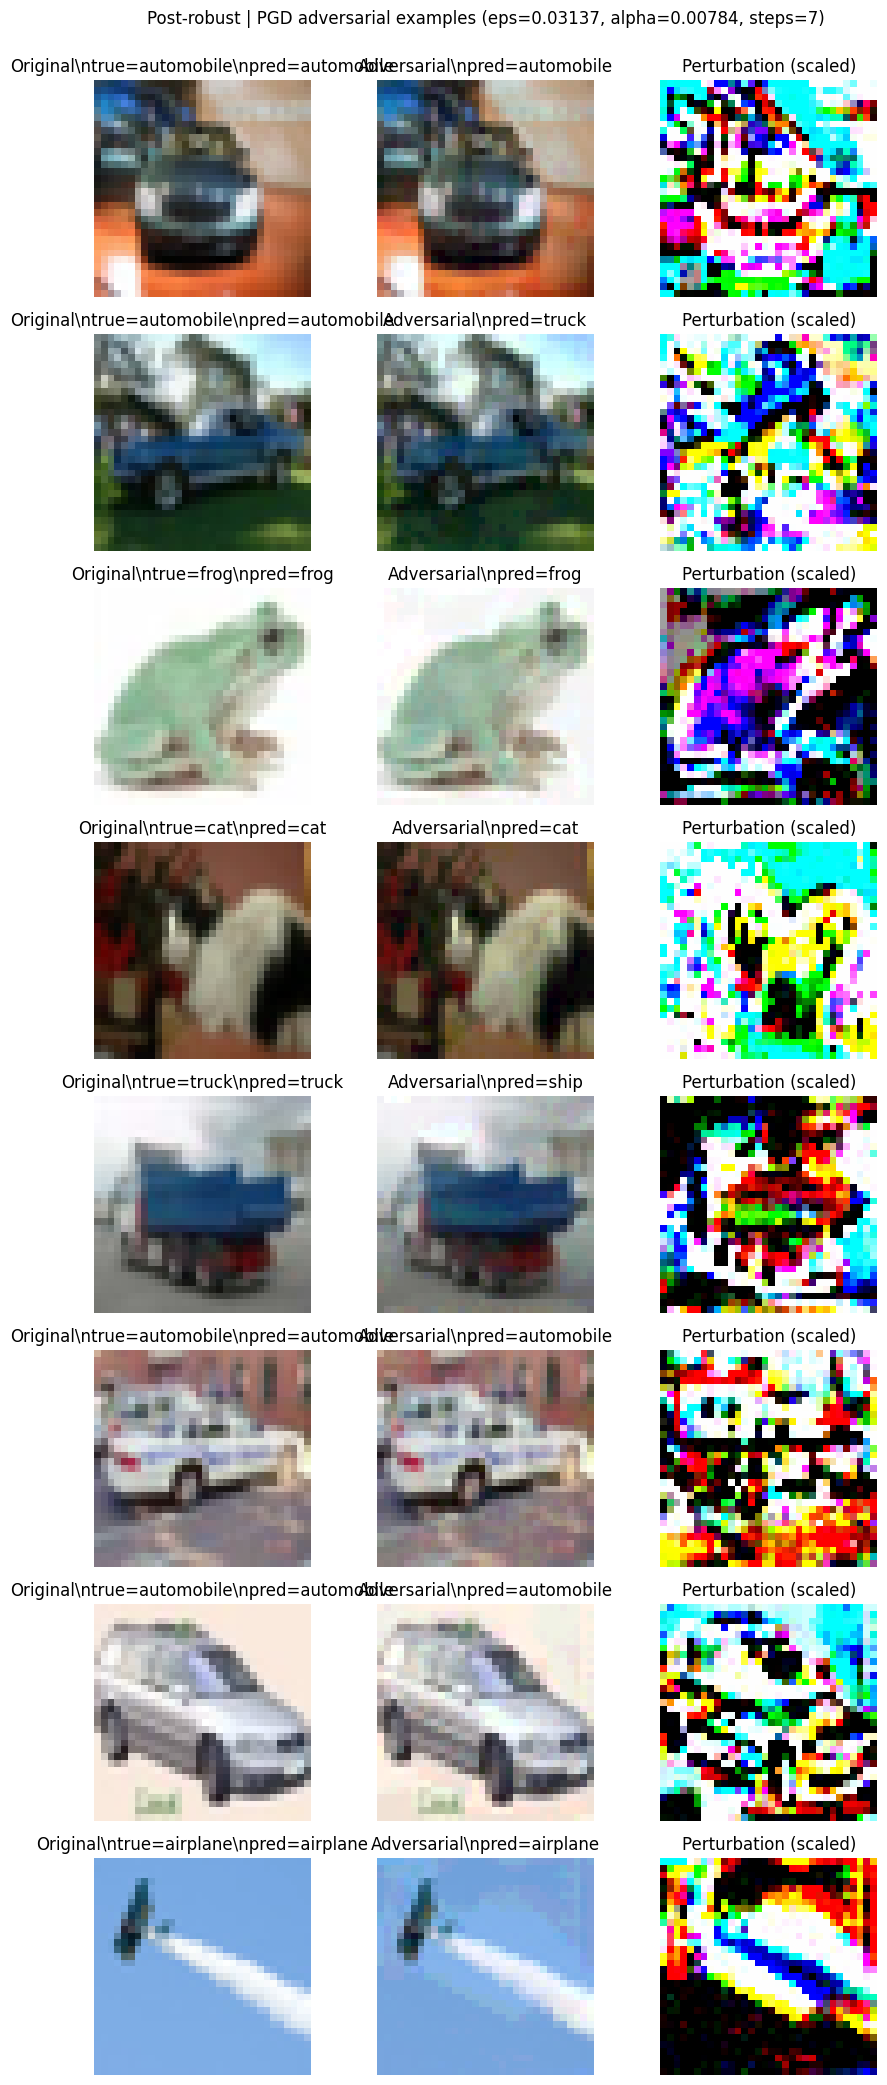

In [ ]:
#P3 cell 6: adversarial example visualisation (original vs attacked) for report figures

def denorm_to_pixel(x_norm):
    x = x_norm * _CIFAR_STD_TF + _CIFAR_MEAN_TF
    return tf.clip_by_value(x, 0.0, 1.0)

def select_correctly_classified_examples(model, x, y, n=8, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    rng.shuffle(idx)
    chosen = []
    for i in idx:
        xb = tf.convert_to_tensor(x[i:i+1], dtype=tf.float32)
        pred = model(xb, training=False)
        pred_cls = int(tf.argmax(pred, axis=1).numpy()[0])
        if pred_cls == int(y[i]):
            chosen.append(int(i))
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        raise RuntimeError(f"Only found {len(chosen)} correctly-classified samples (needed {n}).")
    return chosen

def plot_adv_examples_grid(model, x, y, class_names, eps=8/255, alpha=2/255, steps=5, n=8, seed=0, save_path=None, title_prefix=""):
    idxs = select_correctly_classified_examples(model, x, y, n=n, seed=seed)
    xb = tf.convert_to_tensor(x[idxs], dtype=tf.float32)
    yb = tf.convert_to_tensor(y[idxs], dtype=tf.int32)

    pred_clean = model(xb, training=False)
    clean_cls = tf.argmax(pred_clean, axis=1, output_type=tf.int32).numpy()

    xb_adv = pgd_linf_attack_tf(
        model, xb, yb,
        eps_pixel=eps, alpha_pixel=alpha, steps=steps,
        random_start=True,
    )
    pred_adv = model(xb_adv, training=False)
    adv_cls = tf.argmax(pred_adv, axis=1, output_type=tf.int32).numpy()

    xb_pix = denorm_to_pixel(xb).numpy()
    xb_adv_pix = denorm_to_pixel(xb_adv).numpy()
    perturb = xb_adv_pix - xb_pix

    n_rows = n
    fig, axes = plt.subplots(n_rows, 3, figsize=(9, 2.6 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for r in range(n_rows):
        axes[r, 0].imshow(xb_pix[r])
        axes[r, 0].set_title(f"Original\\ntrue={class_names[int(yb.numpy()[r])]}\\npred={class_names[int(clean_cls[r])]}")
        axes[r, 0].axis("off")

        axes[r, 1].imshow(np.clip(xb_adv_pix[r], 0, 1))
        axes[r, 1].set_title(f"Adversarial\\npred={class_names[int(adv_cls[r])]}")
        axes[r, 1].axis("off")

        # Visualize perturbation (scaled for visibility)
        pert_vis = perturb[r]
        max_abs = np.max(np.abs(pert_vis)) + 1e-8
        pert_vis = 0.5 + 0.5 * (pert_vis / max_abs)
        axes[r, 2].imshow(np.clip(pert_vis, 0, 1))
        axes[r, 2].set_title("Perturbation (scaled)")
        axes[r, 2].axis("off")

    title = f"{title_prefix} PGD adversarial examples (eps={eps:.5f}, alpha={alpha:.5f}, steps={steps})"
    fig.suptitle(title, y=1.0)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=180)
    plt.show()

#Baseline model examples (before robust training)

plot_adv_examples_grid(
    p3_model_baseline,
    p3_test_x, p3_test_y,
    class_names=P3_CLASS_NAMES,
    eps=P3.attack_eps,
    alpha=P3.attack_alpha,
    steps=P3.attack_steps,
    n=8,
    seed=P3.seed,
    save_path=P3_OUT / "p3_adv_examples_pre_robust.png",
    title_prefix="Pre-robust |"
)

#Robust model examples (after adversarial training)

plot_adv_examples_grid(
    p3_model,
    p3_test_x, p3_test_y,
    class_names=P3_CLASS_NAMES,
    eps=P3.attack_eps,
    alpha=P3.attack_alpha,
    steps=P3.attack_steps,
    n=8,
    seed=P3.seed + 1,
    save_path=P3_OUT / "p3_adv_examples_post_robust.png",
    title_prefix="Post-robust |"
)


In [ ]:
#P3 cell 8: ablations

from dataclasses import replace
import gc

#Toggle this to False for a fast smoke run.

P3_RUN_STANDARD_ARCH_ABLATION = True

P3_ABLATION_NATURAL_EPOCHS = 4
P3_ABLATION_KEY_ATTACKS = [
    ("clean",       0.0,    0.0,    0),
    ("pgd_8_20_a2", 8/255,  2/255, 20),
    ("pgd_16_20_a2",16/255, 2/255, 20),
]

if not P3_RUN_STANDARD_ARCH_ABLATION:
    print("P3 standard-training/architecture ablation skipped (P3_RUN_STANDARD_ARCH_ABLATION=False).")
else:
    print("Running compact P3 ablation (standard-training hyper-parameters + architecture) ...")

    ablation_rows = []
    test_ds_ab = make_p3_eval_ds(p3_test_x, p3_test_y, P3.eval_batch_size)

    def _record_key_attacks(model, variant_name, cfg_for_eval, stage_note):

        #Clean

        clean = evaluate_dataset_clean(model, test_ds_ab, label_smoothing=cfg_for_eval.natural_label_smoothing)
        ablation_rows.append({
            "variant": variant_name,
            "category": stage_note,
            "attack": "clean",
            "eps": 0.0,
            "alpha": 0.0,
            "steps": 0,
            "acc": clean["acc"],
            "loss": clean["loss"],
        })

        #Adversarial attacks

        for atk_name, eps, alpha, steps in P3_ABLATION_KEY_ATTACKS:
            if atk_name == "clean":
                continue
            adv = evaluate_dataset_adv(
                model, test_ds_ab,
                eps_pixel=float(eps),
                alpha_pixel=float(alpha),
                steps=int(steps),
                random_start=True,
                label_smoothing=cfg_for_eval.natural_label_smoothing,
            )
            ablation_rows.append({
                "variant": variant_name,
                "category": stage_note,
                "attack": atk_name,
                "eps": float(eps),
                "alpha": float(alpha),
                "steps": int(steps),
                "acc": adv["acc"],
                "loss": adv["loss"],
            })

    def _build_ablation_cfg(**kwargs):
        cfgv = replace(P3, **kwargs)
        cfgv.seed = P3.seed
        cfgv.natural_batch_size = int(P3.natural_batch_size)
        cfgv.robust_batch_size = int(P3.robust_batch_size)
        cfgv.natural_label_smoothing = float(cfgv.label_smoothing)
        cfgv.robust_label_smoothing = float(cfgv.label_smoothing)
        cfgv.attack_eps = float(P3.attack_eps)
        cfgv.attack_alpha = float(P3.attack_alpha)
        cfgv.attack_steps = int(P3.attack_steps)
        cfgv.attack_random_start = bool(P3.attack_random_start)
        cfgv.eval_adv_every_epoch = False  # speed up ablations; key attacks are evaluated after training
        cfgv.natural_augment = True
        cfgv.robust_augment = True
        cfgv.eps_sweep = tuple(float(e) for e in (0.0, 8/255, 16/255))
        cfgv.pgd_eval_setups = (
            ("pgd_8_20step_a2", 8/255, 2/255, 20),
            ("pgd_16_20step_a2", 16/255, 2/255, 20),
        )
        return cfgv

    #Baseline (already trained/loaded pre-robust model from cell 5)

    _record_key_attacks(
        p3_model_baseline,
        variant_name="baseline_p2_or_natural_stageA",
        cfg_for_eval=P3,
        stage_note="baseline_pre_robust"
    )

    #Variant A (standard-training hyper-parameters): no label smoothing + no augmentation

    tf.keras.backend.clear_session()
    cfg_hp = _build_ablation_cfg(
        natural_epochs=P3_ABLATION_NATURAL_EPOCHS,
        label_smoothing=0.0,
    )
    cfg_hp.natural_augment = False
    cfg_hp.report_title = str(P3.report_title) + " | ablation_hp_noLS_noAug"
    model_hp = make_p3_model(cfg_hp)
    _ = model_hp(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)
    log_hp = fit_natural_stage(model_hp, cfg_hp)
    if len(log_hp):
        log_hp.to_csv(P3_OUT / "p3_ablation_hparam_noLS_noAug_natural_log.csv", index=False)
    _record_key_attacks(
        model_hp,
        variant_name="hparam_noLS_noAug",
        cfg_for_eval=cfg_hp,
        stage_note="standard_training_ablation"
    )
    del model_hp
    gc.collect()

    #Variant B (architecture): narrower WRN-28-4 (same standard training recipe)

    tf.keras.backend.clear_session()
    cfg_arch = _build_ablation_cfg(
        natural_epochs=P3_ABLATION_NATURAL_EPOCHS,
        wrn_widen_factor=4,
        model_variant="wrn28x10_p2style_cifar10",  # builder reads widen_factor from cfg
    )
    cfg_arch.report_title = str(P3.report_title) + " | ablation_arch_wrn28x4"
    model_arch = make_p3_model(cfg_arch)
    _ = model_arch(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)
    log_arch = fit_natural_stage(model_arch, cfg_arch)
    if len(log_arch):
        log_arch.to_csv(P3_OUT / "p3_ablation_arch_wrn28x4_natural_log.csv", index=False)
    _record_key_attacks(
        model_arch,
        variant_name="arch_wrn28x4",
        cfg_for_eval=cfg_arch,
        stage_note="architecture_ablation"
    )
    del model_arch
    gc.collect()

    p3_ablation = pd.DataFrame(ablation_rows)
    p3_ablation = p3_ablation.sort_values(["variant", "attack", "eps", "steps"]).reset_index(drop=True)
    p3_ablation.to_csv(P3_OUT / "p3_standard_training_arch_ablation.csv", index=False)

    print("\nSaved compact standard-training/architecture robustness ablation:")
    print(P3_OUT / "p3_standard_training_arch_ablation.csv")
    print(p3_ablation)

    #Small pivot (accuracy only) for report-ready comparison

    p3_ablation_pivot = p3_ablation.pivot_table(
        index="variant",
        columns="attack",
        values="acc",
        aggfunc="first"
    ).reset_index()
    p3_ablation_pivot.to_csv(P3_OUT / "p3_standard_training_arch_ablation_pivot_acc.csv", index=False)
    print("\nAccuracy pivot:")
    print(p3_ablation_pivot)


Running compact P3 ablation (standard-training hyper-parameters + architecture) ...

[P3] Natural pre-training (4 epochs target)
  Epoch 01/4 | train acc=0.5266 | val clean acc=0.4895 | test clean acc=0.4859 | 338.8s
  Epoch 02/4 | train acc=0.7103 | val clean acc=0.6434 | test clean acc=0.6375 | 338.1s
  Epoch 03/4 | train acc=0.7731 | val clean acc=0.6539 | test clean acc=0.6381 | 338.6s
  Epoch 04/4 | train acc=0.8064 | val clean acc=0.6288 | test clean acc=0.6256 | 337.9s

[P3] Natural pre-training (4 epochs target)
  Epoch 01/4 | train acc=0.5201 | val clean acc=0.5168 | test clean acc=0.5130 | 343.6s
  Epoch 02/4 | train acc=0.6880 | val clean acc=0.6025 | test clean acc=0.5993 | 342.2s
  Epoch 03/4 | train acc=0.7424 | val clean acc=0.6292 | test clean acc=0.6196 | 343.1s
  Epoch 04/4 | train acc=0.7757 | val clean acc=0.7217 | test clean acc=0.7078 | 342.6s

Saved compact standard-training/architecture robustness ablation:
/content/drive/MyDrive/ST456_P3_outputs/p3_outputs_wrn_